# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 46 |  |
| :-------------|:-------------|
| Tim Omloo | 6567010 |
| Marjoksi Elyas| 6243355 |
| Steven Wijnands| 6580912|

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tim', 'Marjoksi','Steven']

## Opdracht 1: Planning.

| Planning Groep: 46     |Tijdstip / Tijdspanne  |
|---|---|
| Voorbereiding | 11:00 - 11:15 |
| Kalibreren sensor | 11:15 - 11:45|
| Meetopsteling testen | 11:45 - 12:00 |
| Iteratie 1 begin | 12:00 - 12:30 |
| Pauze | 12:30 - 13:30 |
| Iteratie 1 | 13:30 - 15:30 |
| Iteratie 2 | 15:30 - 16:30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [nummer]
<img src="tudelftLogo.png" width="400">

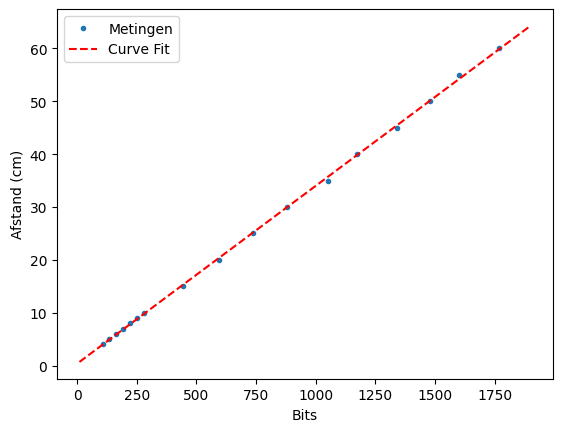

[0.03363692 0.34863315]


In [3]:
# verwerk hier jullie kalibratiemetingen
from scipy.optimize import curve_fit

bits = np.array([110,135,165,193,223,250,280,444,596,737,882,1050,1174,1340,1480,1600,1770]) #bits
afstanden = np.array([4,5,6,7,8,9,10,15,20,25,30,35,40,45,50,55,60]) #cm

def fit(x,a,b):
    return a*x + b

ppov,pcov = curve_fit(fit,bits,afstanden)
x_test = np.linspace(10,1900,1000)

plt.figure()
plt.plot(bits,afstanden,'.',label='Metingen')
plt.plot(x_test,fit(x_test,*ppov),'r--',label='Curve Fit')
plt.xlabel('Bits')
plt.ylabel('Afstand (cm)')
plt.legend()
plt.show()

print(ppov)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  48.1
1   0  30   0  20  48.8
2  40   0  30   0  46.8
3  30   0  20   0  46.1


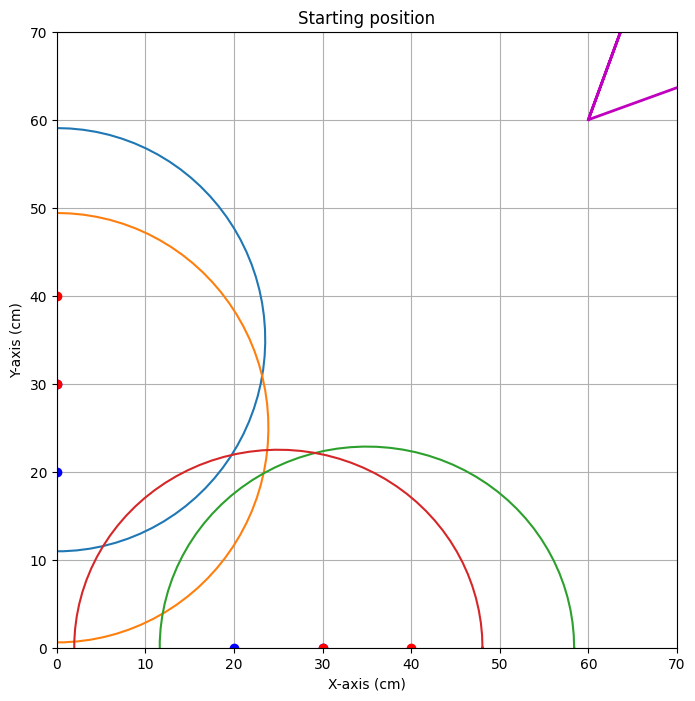


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=94.505


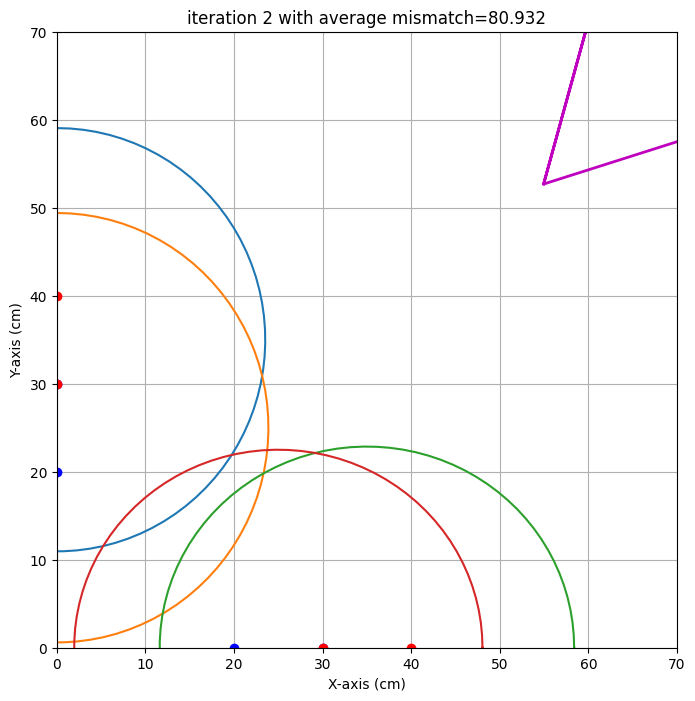

end iteration 2 with average mismatch=80.932


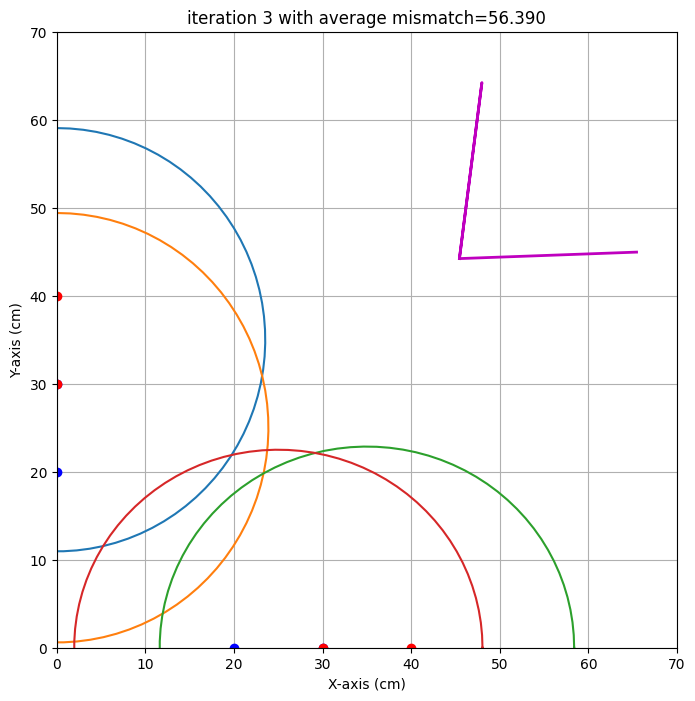

end iteration 3 with average mismatch=56.390


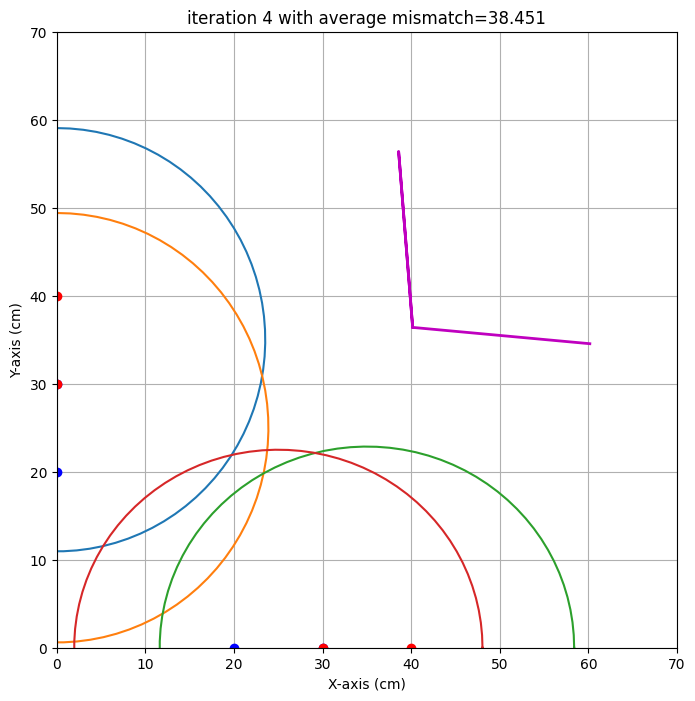

end iteration 4 with average mismatch=38.451


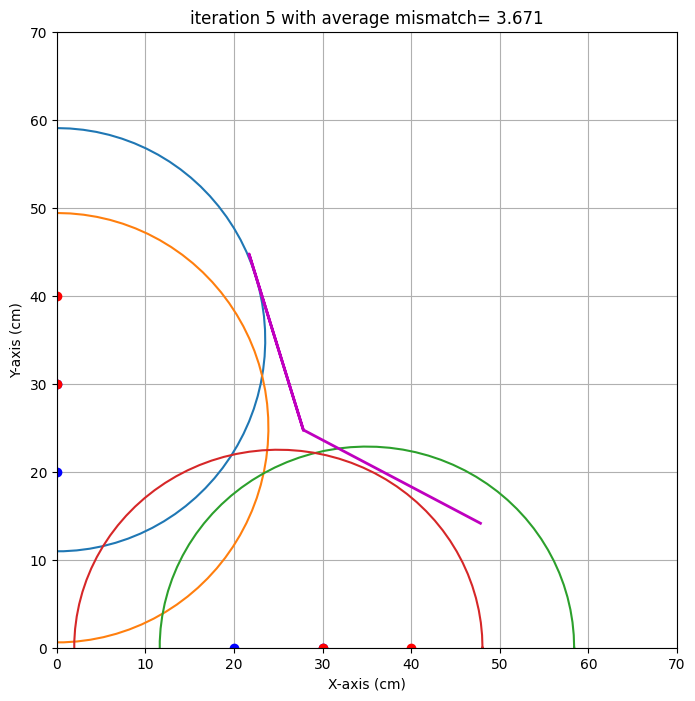

end iteration 5 with average mismatch= 3.671


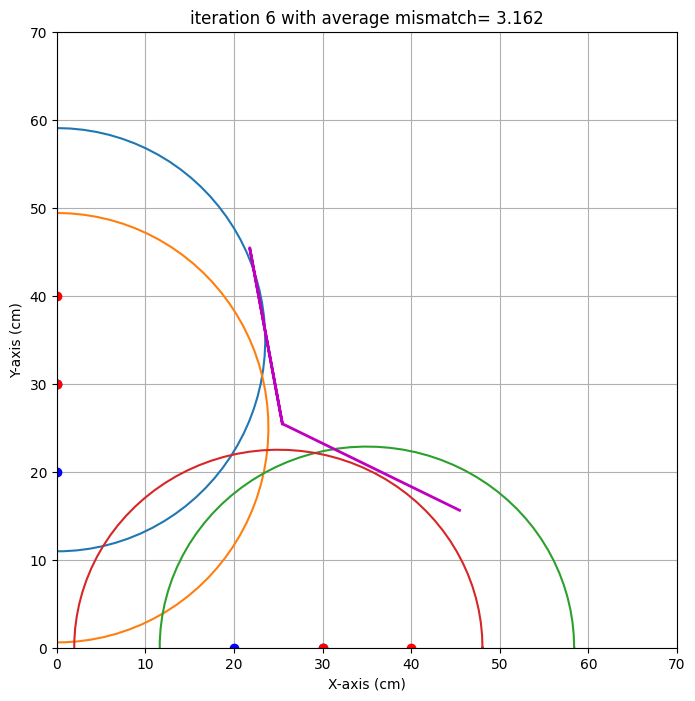

end iteration 6 with average mismatch= 3.162


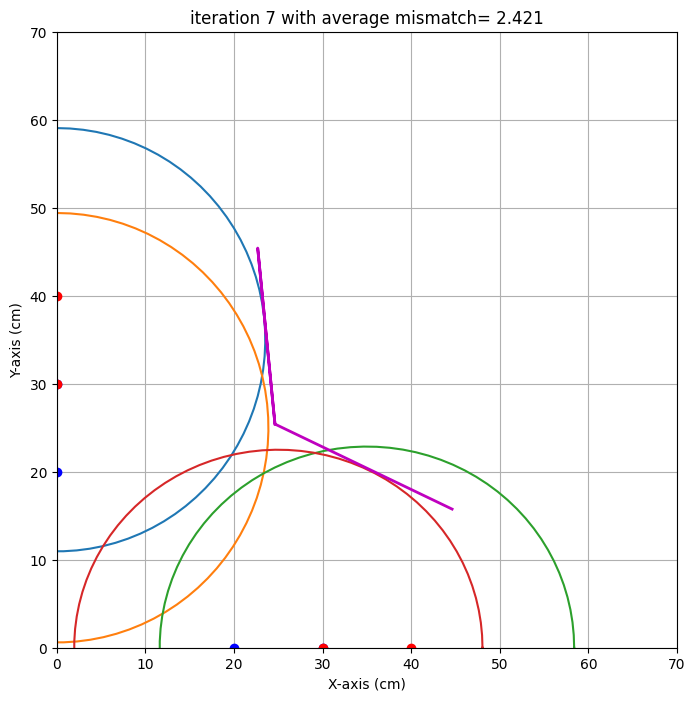

end iteration 7 with average mismatch= 2.421


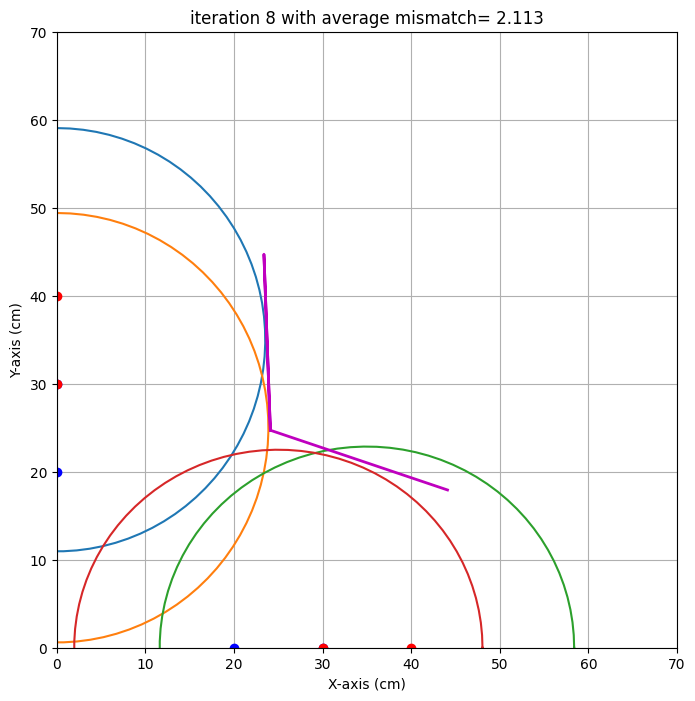

end iteration 8 with average mismatch= 2.113
end iteration 9 with average mismatch= 1.954
end iteration 10 with average mismatch= 1.874
end iteration 11 with average mismatch= 1.867
end iteration 12 with average mismatch= 1.867
end iteration 13 with average mismatch= 1.807
end iteration 14 with average mismatch= 1.733


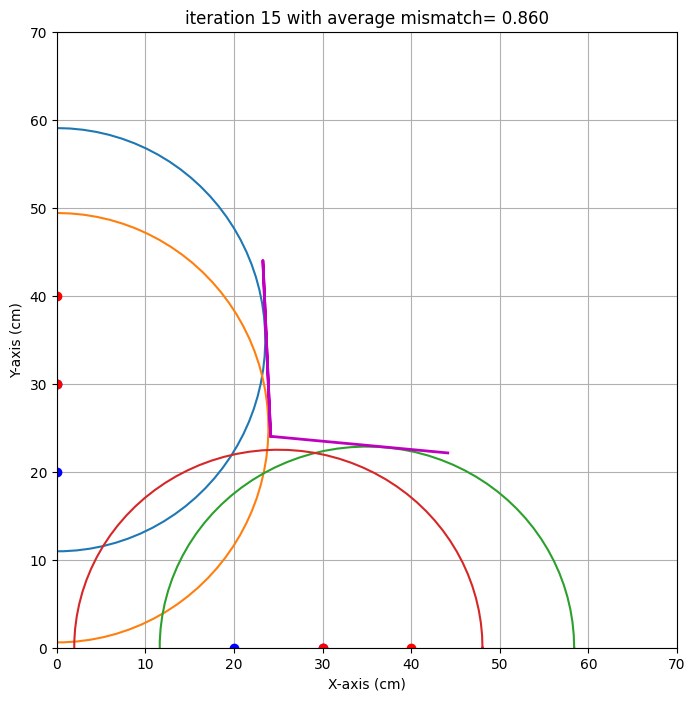

end iteration 15 with average mismatch= 0.860


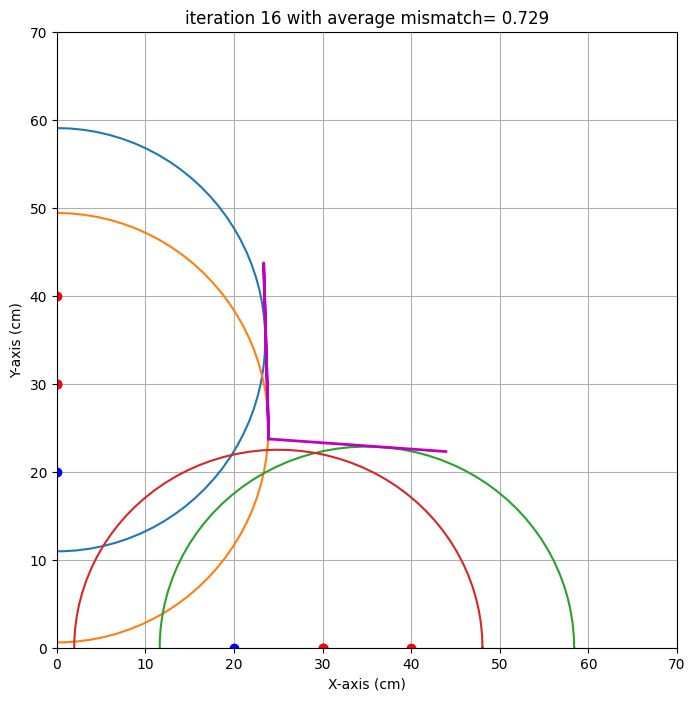

end iteration 16 with average mismatch= 0.729
end iteration 17 with average mismatch= 0.720
end iteration 18 with average mismatch= 0.719


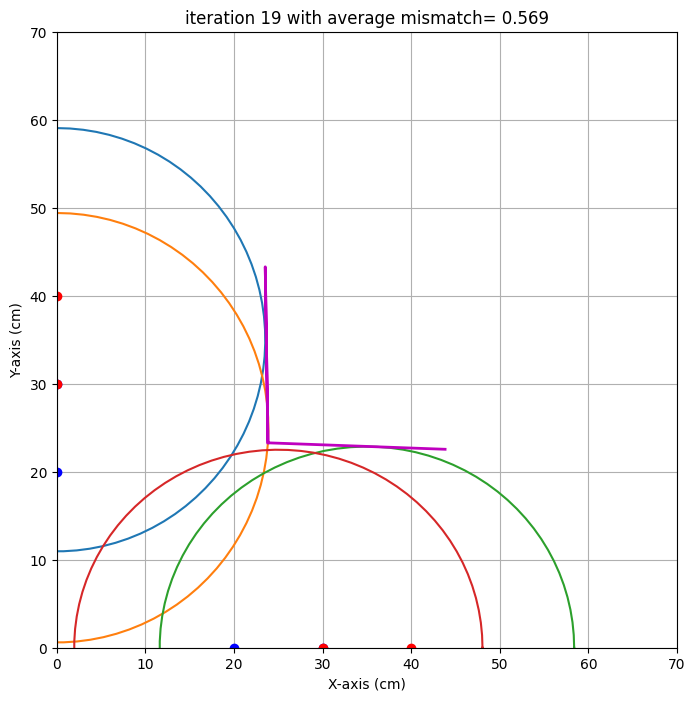

end iteration 19 with average mismatch= 0.569


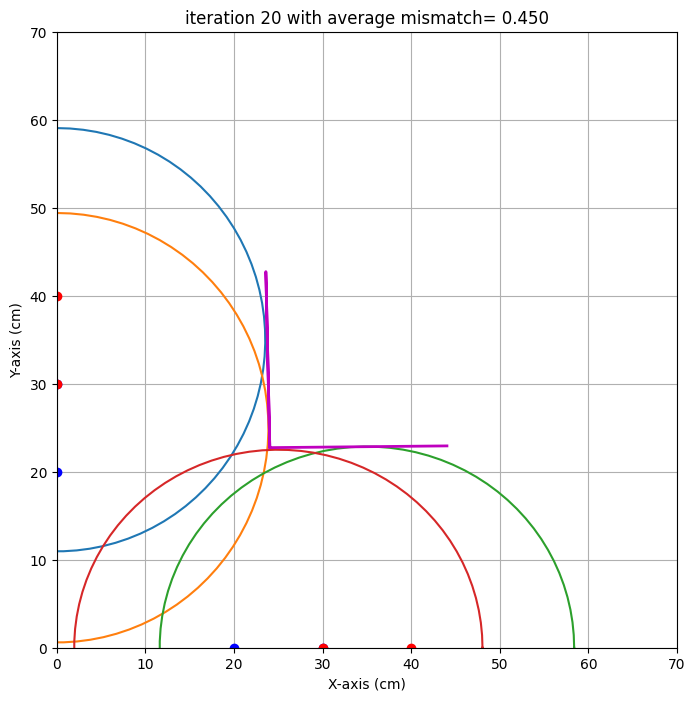

end iteration 20 with average mismatch= 0.450


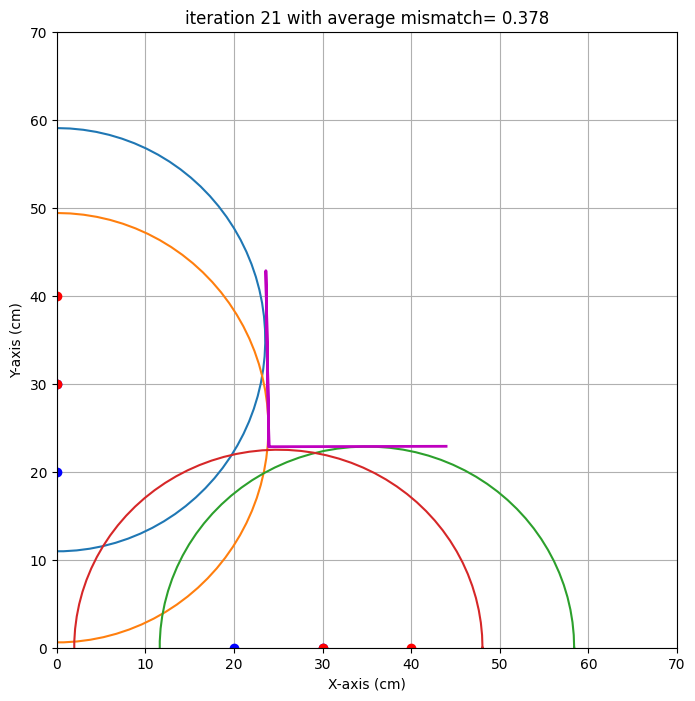

end iteration 21 with average mismatch= 0.378
end iteration 22 with average mismatch= 0.355
end iteration 23 with average mismatch= 0.354
end iteration 24 with average mismatch= 0.354
end iteration 25 with average mismatch= 0.353
end iteration 26 with average mismatch= 0.353
end iteration 27 with average mismatch= 0.353
end iteration 28 with average mismatch= 0.353
end iteration 29 with average mismatch= 0.353
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.353
###############################################################################
end of iteration  30
Best alpha=   0.13 with uncertainty=   3.58
Best beta =  -1.00 with uncertainty=   0.43
Best x0   =  23.92 with uncertainty=   0.03
Best y0   =  22.82 with uncertainty=   0.39
###############################################################################


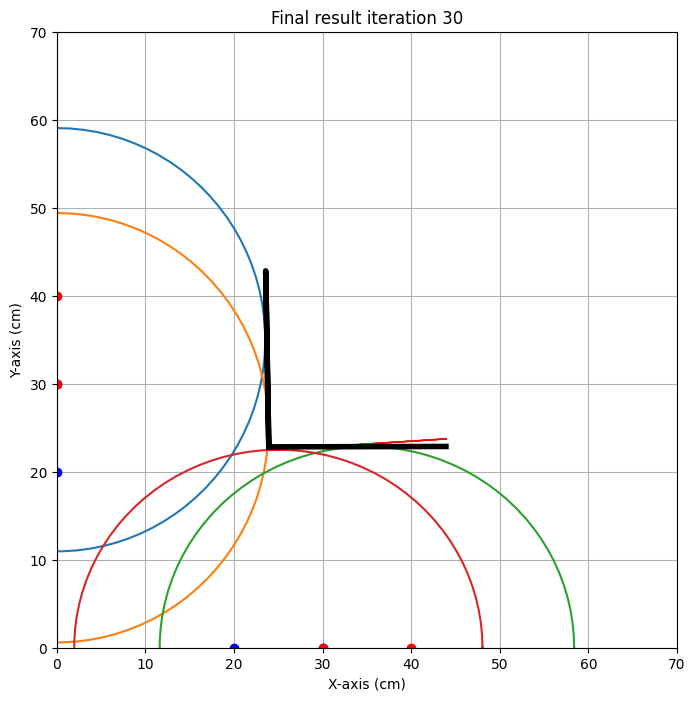

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

#origin is 2.5 centimeter naar achter geplaats, waardoor het karton niet op 20 maar 22.5 cm staat.

dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,48.1],
    [0,30,0,20,48.8],
#   [0,10,0,20,170.0],
    [40,0,30,0,46.8],
    [30,0,20,0,46.1],
#    [10,0,20,0,165.0],
#   [10,0,0,10,180.0]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 23.9 cm met een standaardafwijking van 0.0 cm 
y0: 22.8 cm met een standaardafwijking van 0.4 cm 
alpha: 0.1 graden met een standaardafwijking van 3.6 graad 
beta: -1.0 graden met een standaardafwijking van 0.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Tim]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Tim.png" width="400">

#### algoritme [Marjoksi]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Marjoksi.png" width="400">

#### algoritme [Steven]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Steven.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 33,
           'y0': 23.5,
           'alpha' : 14,
           'beta' : 10
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Steven' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
   #[0,70,0,60,170] ongeldig
   [0,30,0,20,64.8],
   [0,40,0,30,62.3],
   [0,20,0,10,62.8],
   #[70,0,60,0,130] ongeldig 
   [30,0,20,0,53.0],
   [40,0,30,0,48.1]
    ]),
  'Marjoksi' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20,0,10,0,170] ongeldig
    [30,0,20,0,54.1],
    [40,0,30,0,53.3],
    [50,0,40,0,44.1],
    #[60,0,50,0,180] ongeldig
    [0,30,0,20,63.1],
    [0,40,0,30,59.7]
    #[0,40,0,50,170] ongeldig

    ]),
    'Tim' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    ])
      }

## Opdracht 7: Evaluatie.

Tim
Running the imaging algorithm with the following data:
Empty DataFrame
Columns: [xs, ys, xr, yr, R]
Index: []


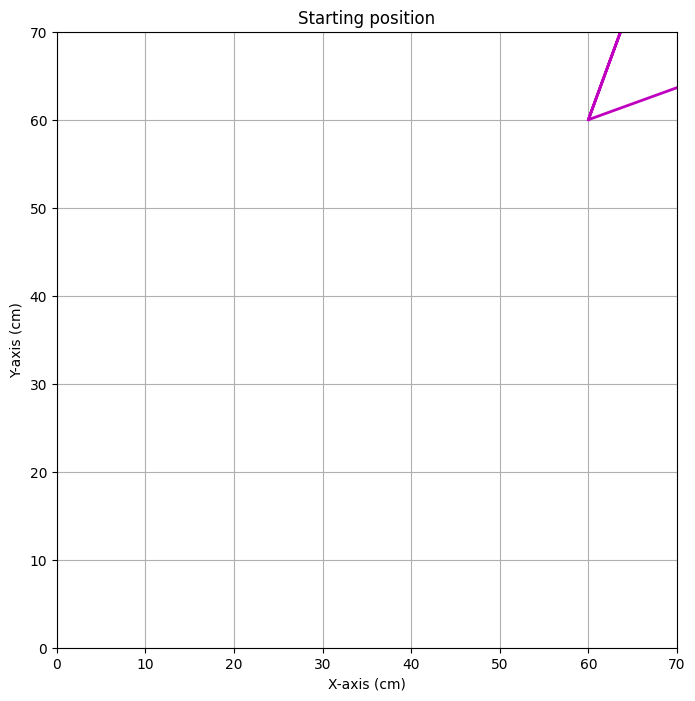


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=   nan
end iteration 2 with average mismatch=   nan
end iteration 3 with average mismatch=   nan
end iteration 4 with average mismatch=   nan
end iteration 5 with average mismatch=   nan
end iteration 6 with average mismatch=   nan
end iteration 7 with average mismatch=   nan
end iteration 8 with average mismatch=   nan
end iteration 9 with average mismatch=   nan
end iteration 10 with average mismatch=   nan
end iteration 11 with average mismatch=   nan
end iteration 12 with average mismatch=   nan
end iteration 13 with average mismatch=   nan
end iteration 14 with average mismatch=   nan
end iteration 15 with average mismatch=   nan
end iteration 16 with average mismatch=   nan
end iteration 17 with average mismatch=   nan
end iteration 18 with average mismatch=   nan
end iteration 19 with average mismatch=   nan
end iteration 20 with average mismatch=   nan
end iteration 21 with ave

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


end iteration 23 with average mismatch=   nan
end iteration 24 with average mismatch=   nan
end iteration 25 with average mismatch=   nan
end iteration 26 with average mismatch=   nan
end iteration 27 with average mismatch=   nan
end iteration 28 with average mismatch=   nan
end iteration 29 with average mismatch=   nan
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch=   nan
###############################################################################
end of iteration  30
Best alpha=    nan with uncertainty=   0.00
Best beta =    nan with uncertainty=   0.00
Best x0   =    nan with uncertainty=   0.00
Best y0   =    nan with uncertainty=   0.00
###############################################################################
no uncertainty found, please run again


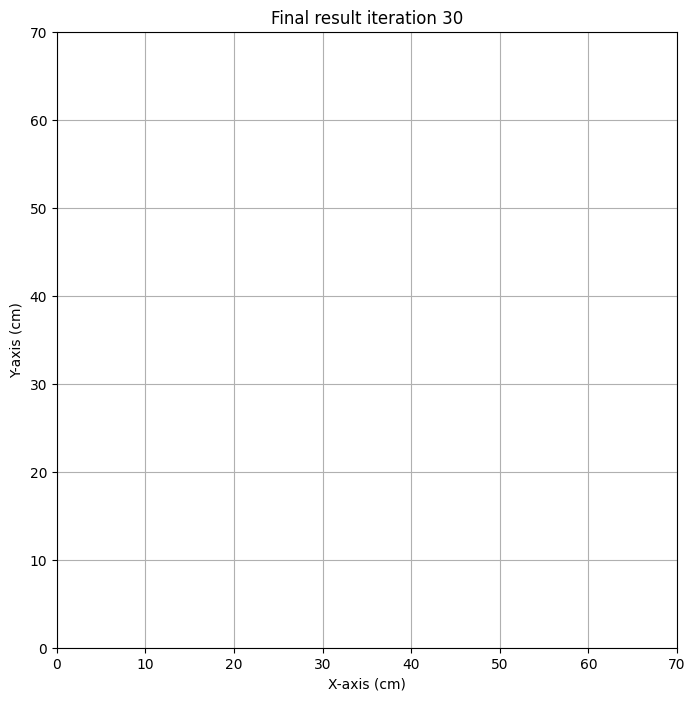

{'alpha': np.float64(nan), 'alpha_eps': 0.0, 'beta': np.float64(nan), 'beta_eps': 0.0, 'x0': np.float64(nan), 'x0_eps': 0.0, 'y0': np.float64(nan), 'y0_eps': 0.0}
Marjoksi
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  20   0  54.1
1  40   0  30   0  53.3
2  50   0  40   0  44.1
3   0  30   0  20  63.1
4   0  40   0  30  59.7


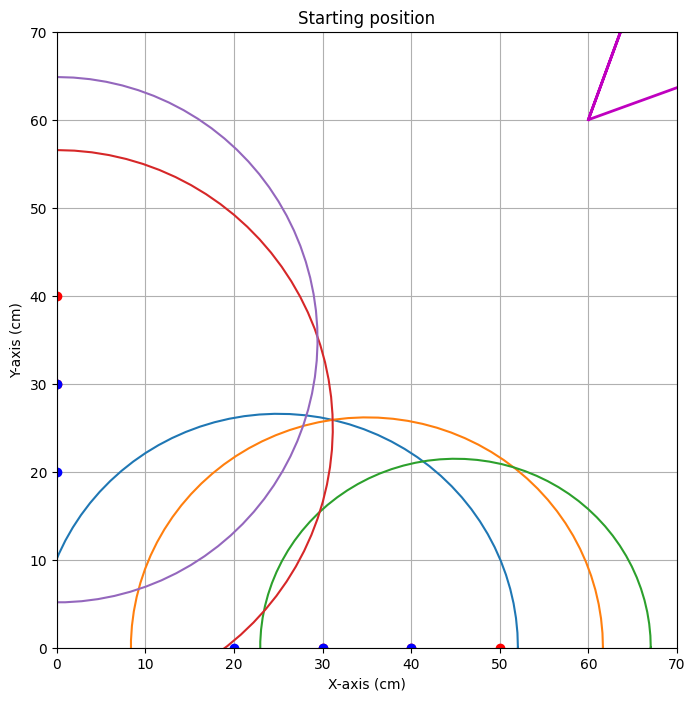


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=85.332


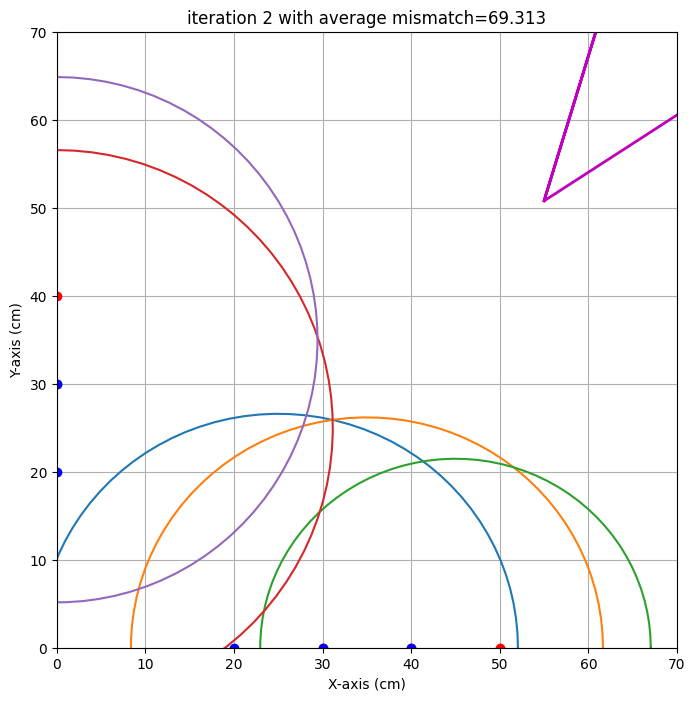

end iteration 2 with average mismatch=69.313


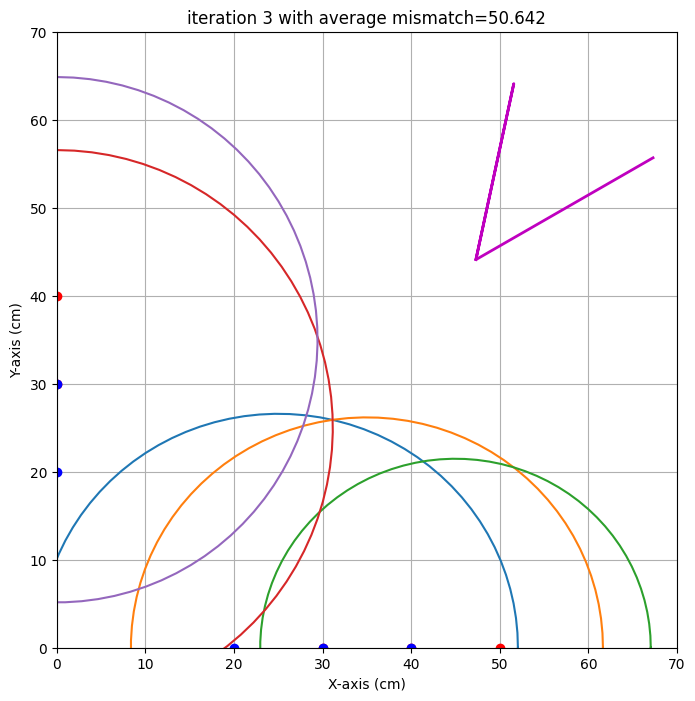

end iteration 3 with average mismatch=50.642


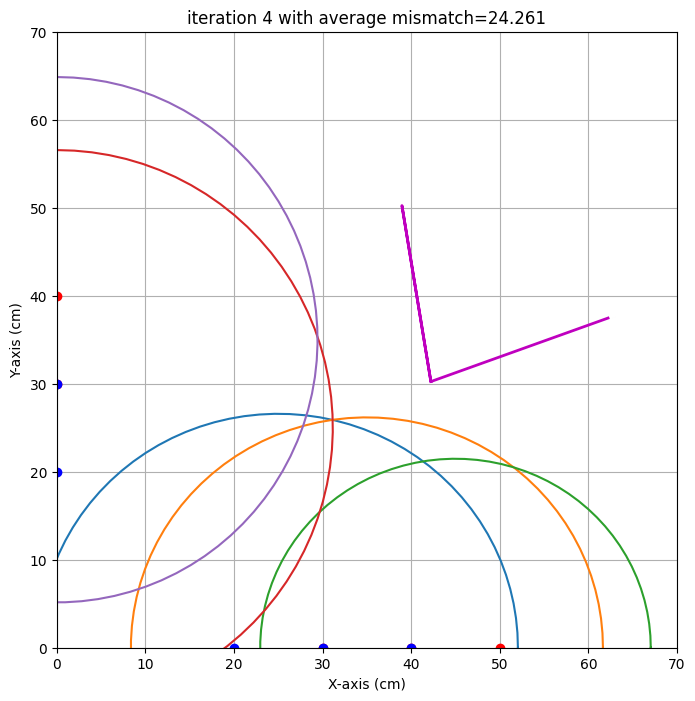

end iteration 4 with average mismatch=24.261


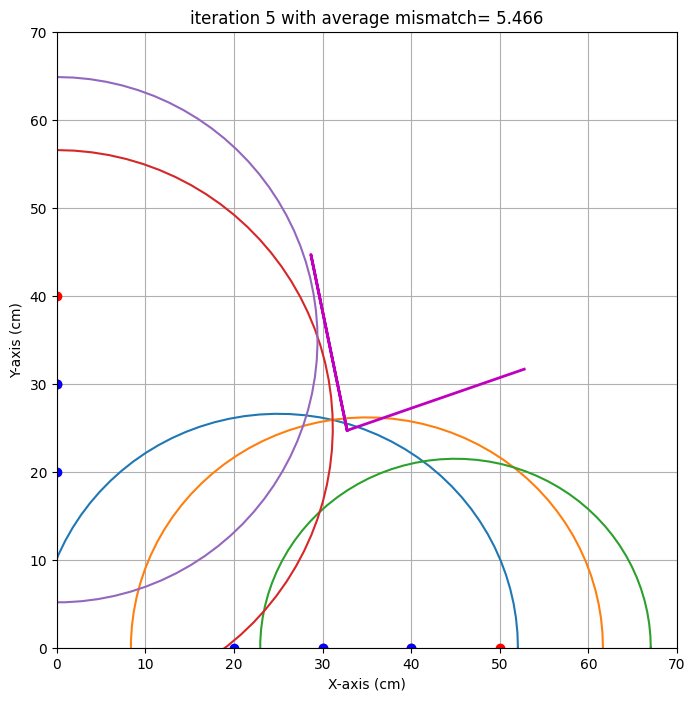

end iteration 5 with average mismatch= 5.466


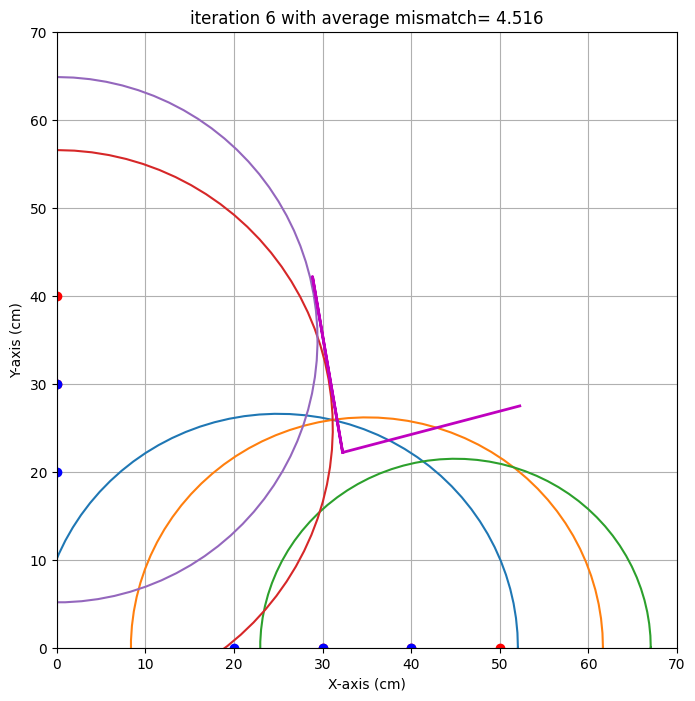

end iteration 6 with average mismatch= 4.516


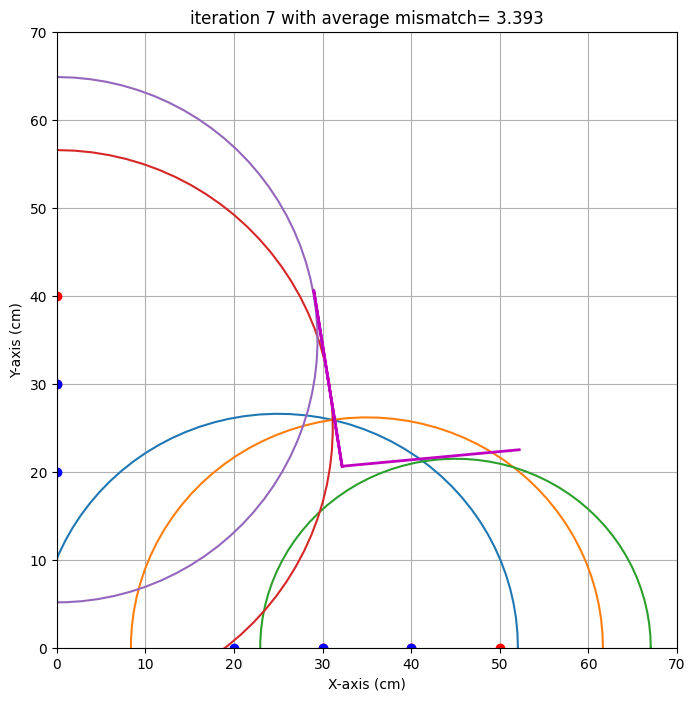

end iteration 7 with average mismatch= 3.393
end iteration 8 with average mismatch= 3.071
end iteration 9 with average mismatch= 3.071


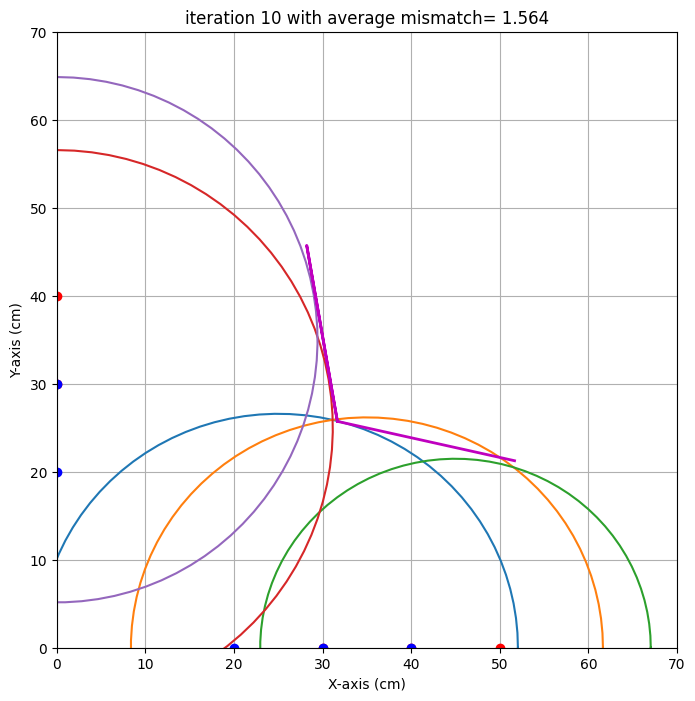

end iteration 10 with average mismatch= 1.564
end iteration 11 with average mismatch= 1.489


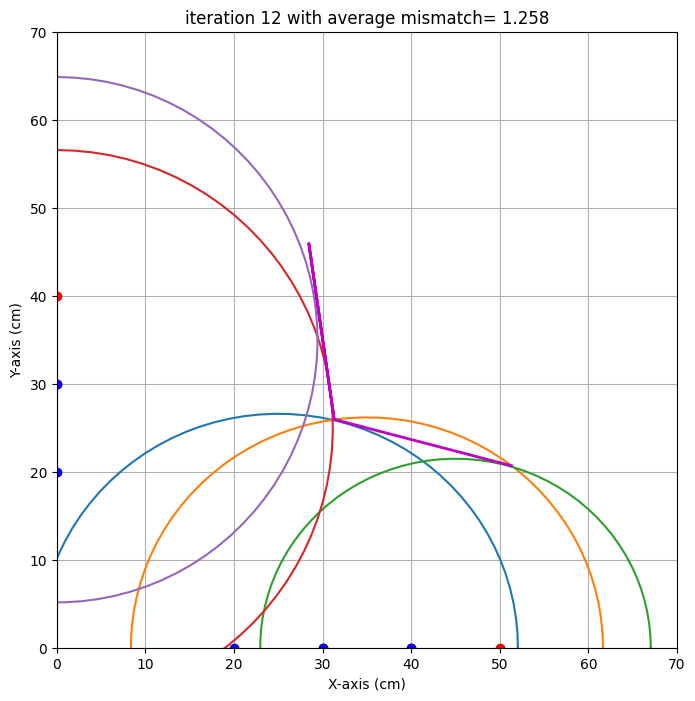

end iteration 12 with average mismatch= 1.258
end iteration 13 with average mismatch= 1.258
end iteration 14 with average mismatch= 1.258
end iteration 15 with average mismatch= 1.258
end iteration 16 with average mismatch= 1.258
end iteration 17 with average mismatch= 1.258
end iteration 18 with average mismatch= 1.134
end iteration 19 with average mismatch= 1.111
end iteration 20 with average mismatch= 1.107
end iteration 21 with average mismatch= 1.105
end iteration 22 with average mismatch= 1.105
end iteration 23 with average mismatch= 1.105
end iteration 24 with average mismatch= 1.105
end iteration 25 with average mismatch= 1.105
end iteration 26 with average mismatch= 1.105
end iteration 27 with average mismatch= 1.105
end iteration 28 with average mismatch= 1.105
end iteration 29 with average mismatch= 1.105
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch

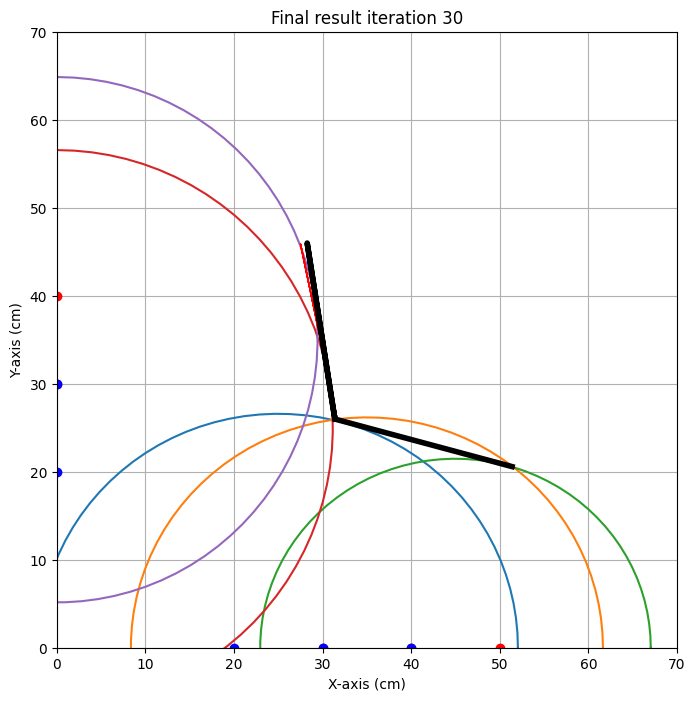

{'alpha': np.float64(-15.114736700238003), 'alpha_eps': np.float64(0.006159667325674079), 'beta': np.float64(-8.89060752993091), 'beta_eps': np.float64(2.8601820829244424), 'x0': np.float64(31.384292783493162), 'x0_eps': np.float64(0.2813510082047408), 'y0': np.float64(25.984904602277055), 'y0_eps': np.float64(0.11729202247475357)}
Steven
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  20  64.8
1   0  40   0  30  62.3
2   0  20   0  10  62.8
3  30   0  20   0  53.0
4  40   0  30   0  48.1


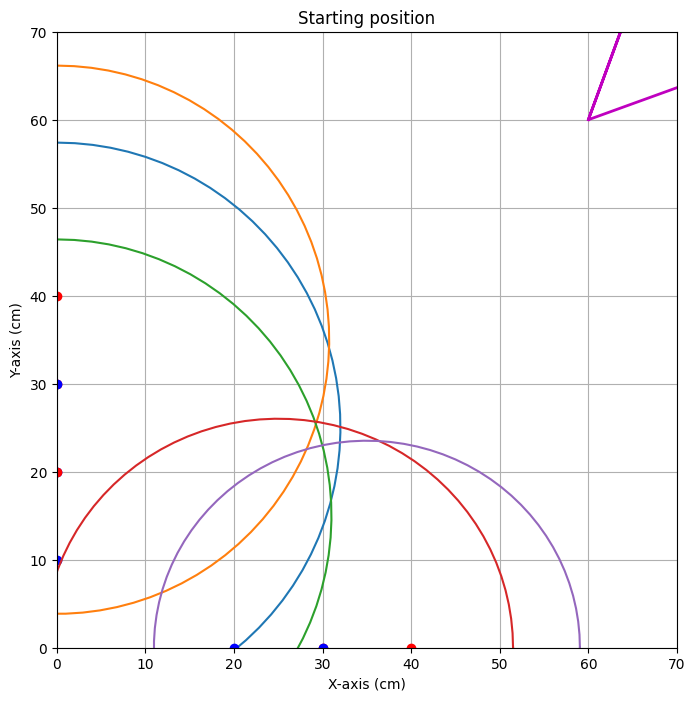


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=86.766


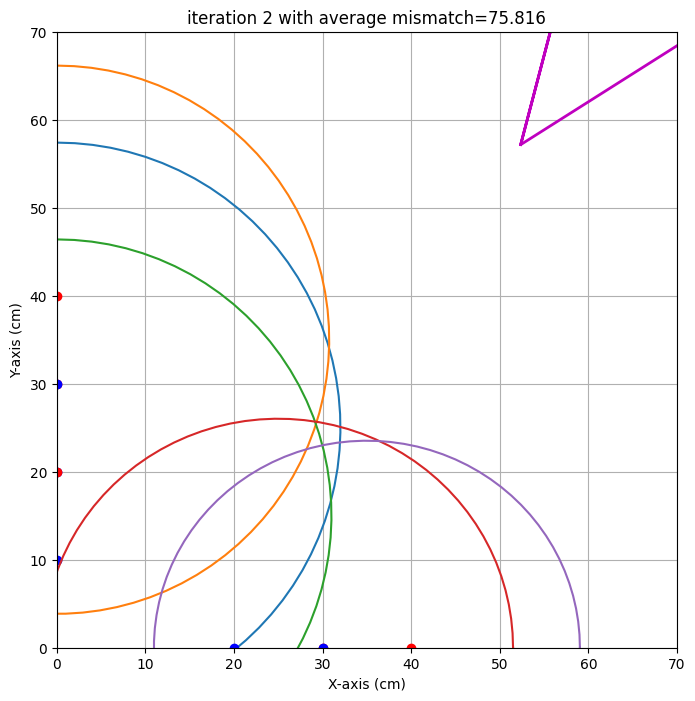

end iteration 2 with average mismatch=75.816


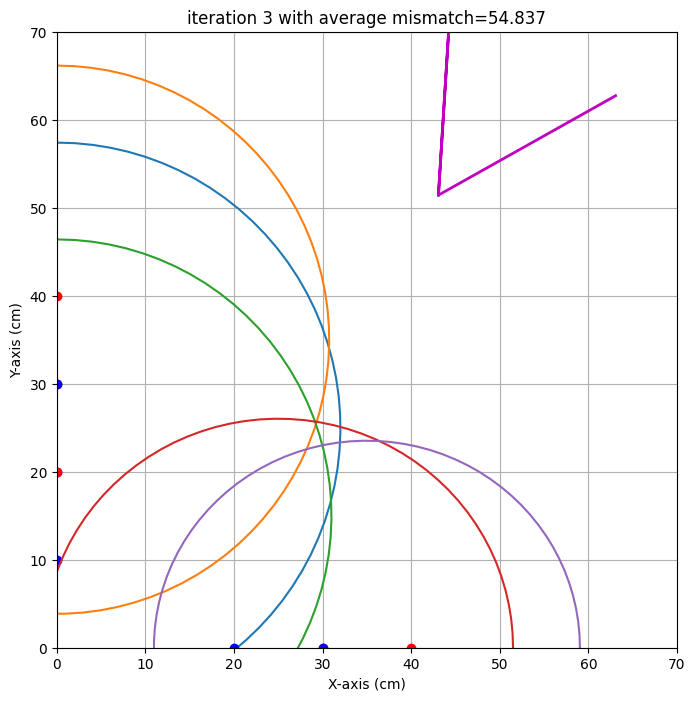

end iteration 3 with average mismatch=54.837


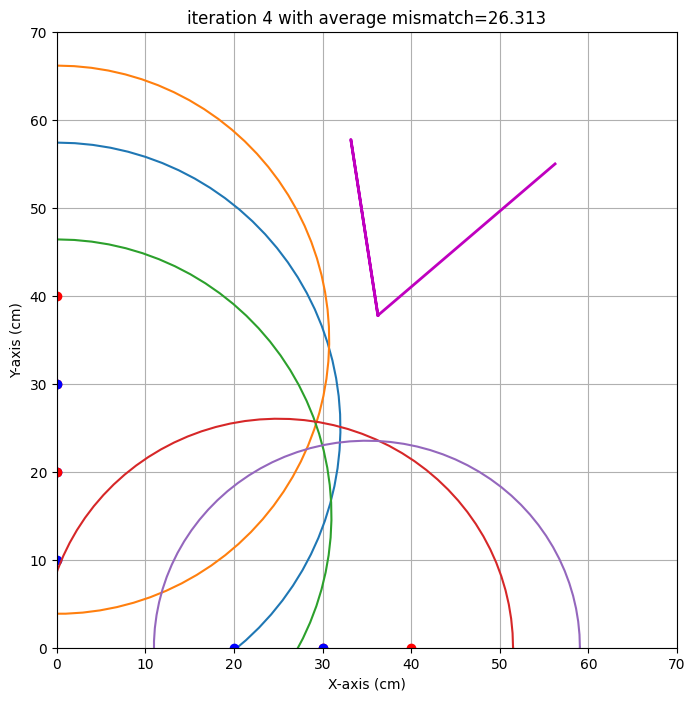

end iteration 4 with average mismatch=26.313


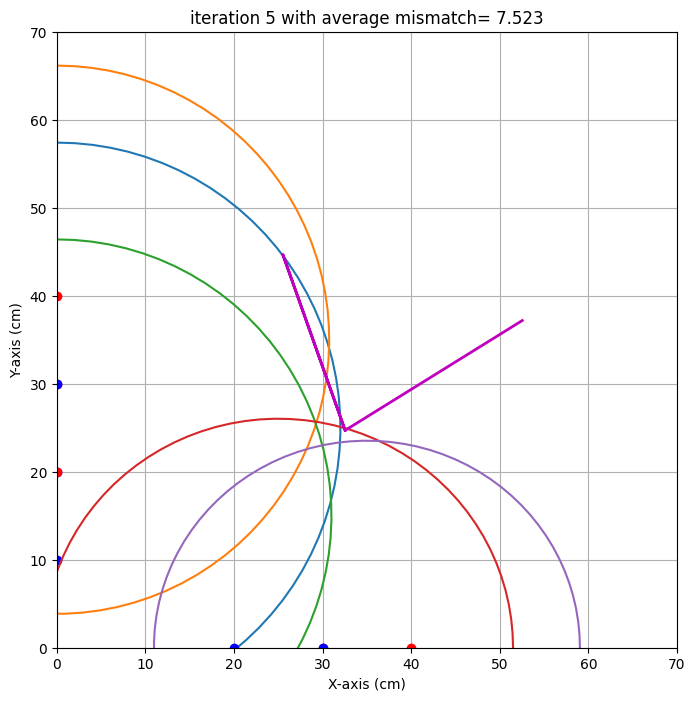

end iteration 5 with average mismatch= 7.523


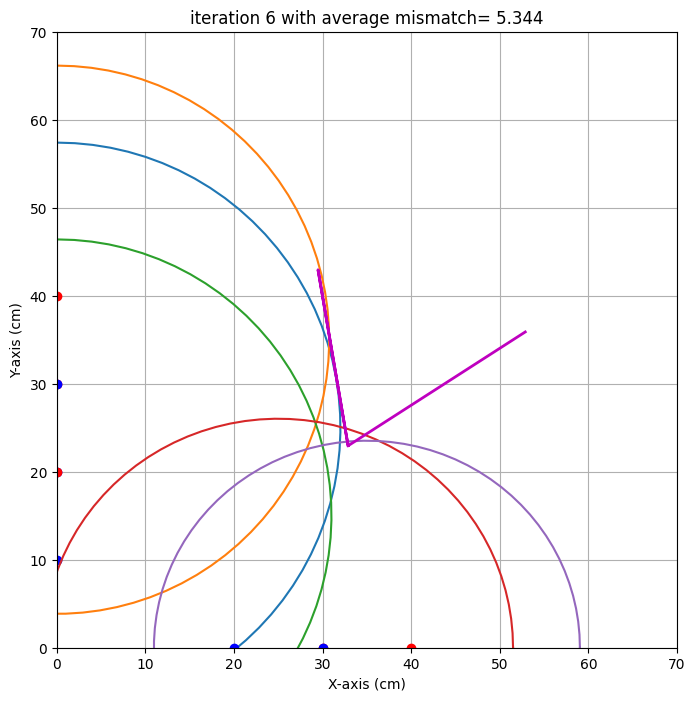

end iteration 6 with average mismatch= 5.344


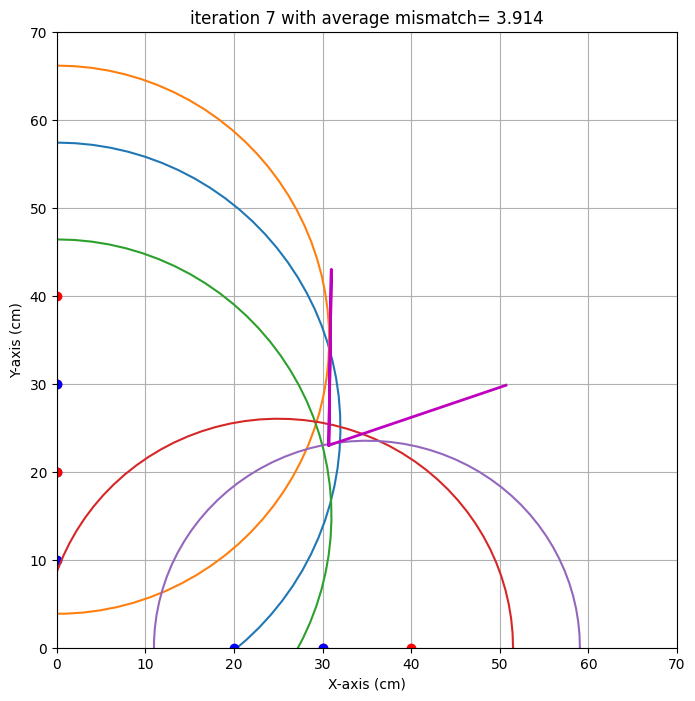

end iteration 7 with average mismatch= 3.914
end iteration 8 with average mismatch= 3.702
end iteration 9 with average mismatch= 3.698
end iteration 10 with average mismatch= 3.698


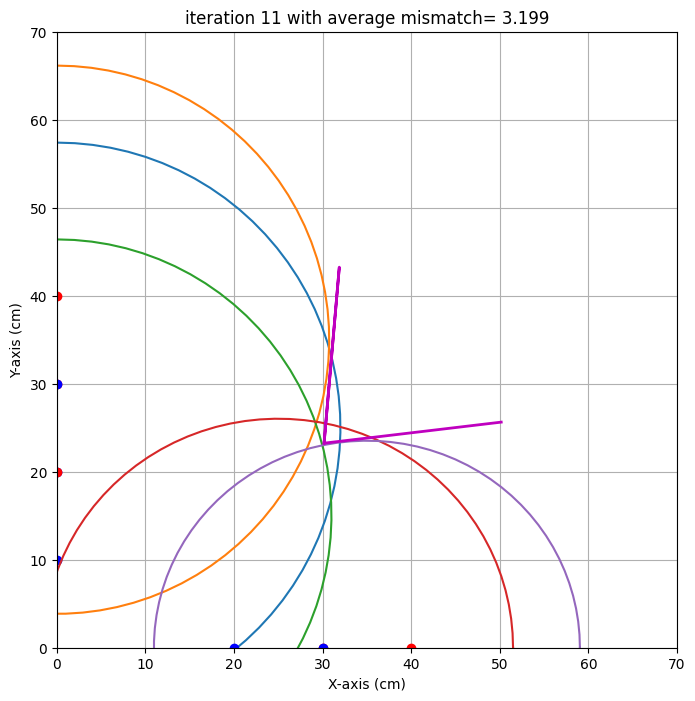

end iteration 11 with average mismatch= 3.199
end iteration 12 with average mismatch= 3.091
end iteration 13 with average mismatch= 2.852


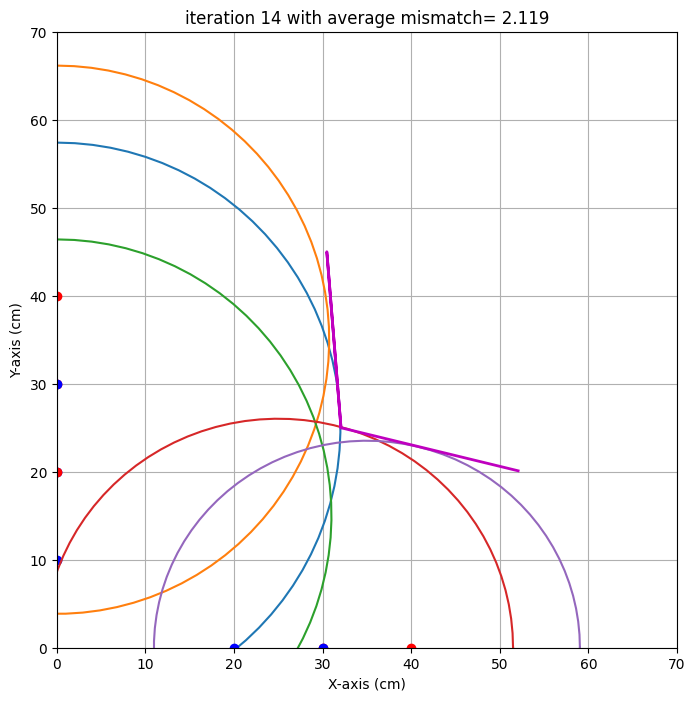

end iteration 14 with average mismatch= 2.119
end iteration 15 with average mismatch= 2.105
end iteration 16 with average mismatch= 2.076
end iteration 17 with average mismatch= 2.015
end iteration 18 with average mismatch= 2.015
end iteration 19 with average mismatch= 2.015
end iteration 20 with average mismatch= 2.015
end iteration 21 with average mismatch= 1.985
end iteration 22 with average mismatch= 1.983
end iteration 23 with average mismatch= 1.983
end iteration 24 with average mismatch= 1.983
end iteration 25 with average mismatch= 1.975
end iteration 26 with average mismatch= 1.860
end iteration 27 with average mismatch= 1.856
end iteration 28 with average mismatch= 1.856
end iteration 29 with average mismatch= 1.856
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.856
###############################################################################
end of iteration  30
Best alp

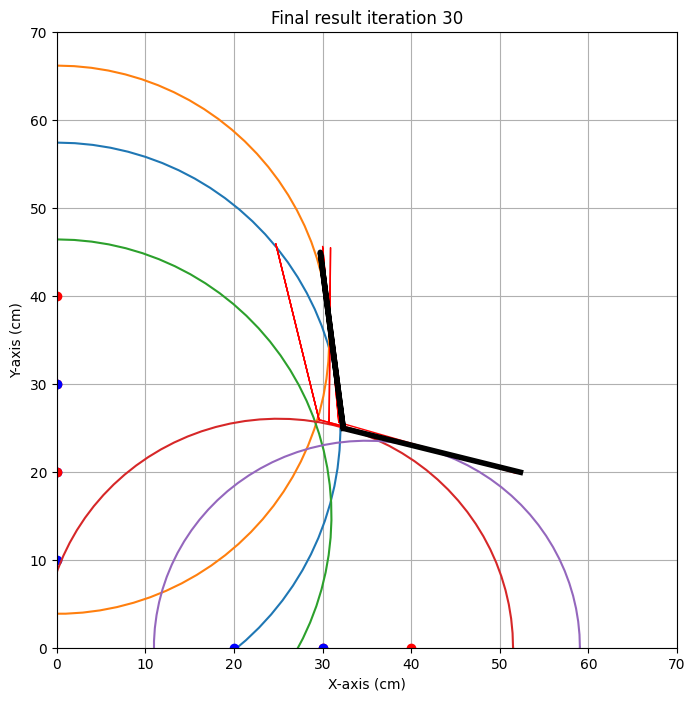

{'alpha': np.float64(-14.018787476190102), 'alpha_eps': np.float64(2.1233579659681716), 'beta': np.float64(-7.389055384227684), 'beta_eps': np.float64(7.830998002143619), 'x0': np.float64(32.332047224684494), 'x0_eps': np.float64(2.7353969327657772), 'y0': np.float64(24.9319539198039), 'y0_eps': np.float64(0.9755205087961372)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tim 
x0 target is : 33.0. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
y0 target is : 23.5. Gevonden waarde: nan cm met een standaardafwijking van 0.0 cm 
alpha target is : 14.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 
beta target is : 10.0. Gevonden waarde: nan graden met een standaardafwijking van 0.0 graad 

Marjoksi 
x0 target is : 33.0. Gevonden waarde: 31.4 cm met een standaardafwijking van 0.3 cm 
y0 target is : 23.5. Gevonden waarde: 26.0 cm met een standaardafwijking van 0.1 cm 
alpha target is : 14.0. Gevonden waarde: -15.1 graden met een standaardafwijking van 0.0 graad 
beta target is : 10.0. Gevonden waarde: -8.9 graden met een standaardafwijking van 2.9 graad 

Steven 
x0 target is : 33.0. Gevonden waarde: 32.3 cm met een standaardafwijking van 2.7 cm 
y0 target is : 23.5. Gevonden waarde: 24.9 cm met een standaardafwijking van 1.0 cm 
alpha target is : 14.0. Gevonden waarde: -14.0 graden met een standaardafwijking van 2.1 g

## Opdracht 8: Iteratie1+.VERVANG DEZE TEKST DOOR DE TIJD WANNEER JE AAN DEZE ITERATIE BEGINT.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Eindalgoritme.png)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  30   0  20   0   72.9
1  40   0  30   0   67.5
2  35   0  25   0   68.8
3   0  70   0  60   93.8
4   0  65   0  55   88.6
5   0  60   0  50  110.0
6   0  55   0  45  100.0
7   0  50   0  40  110.0


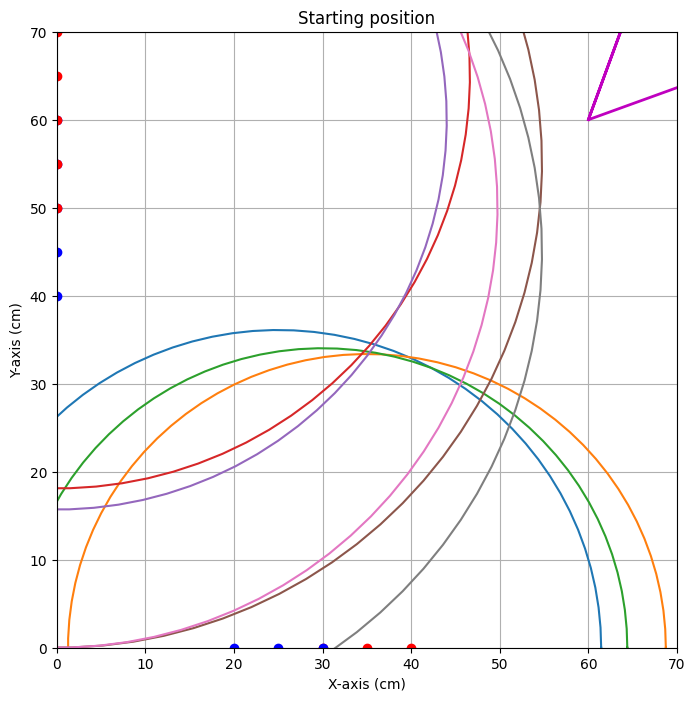


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=42.218


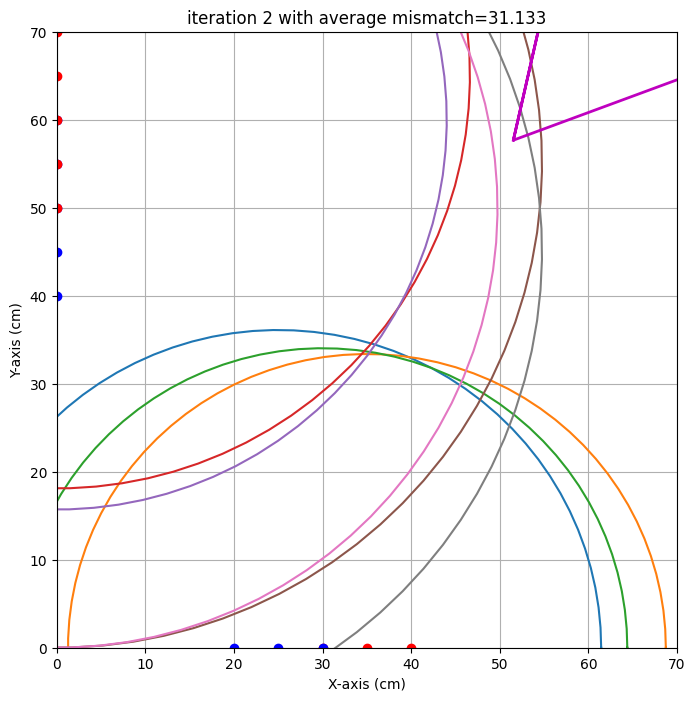

end iteration 2 with average mismatch=31.133


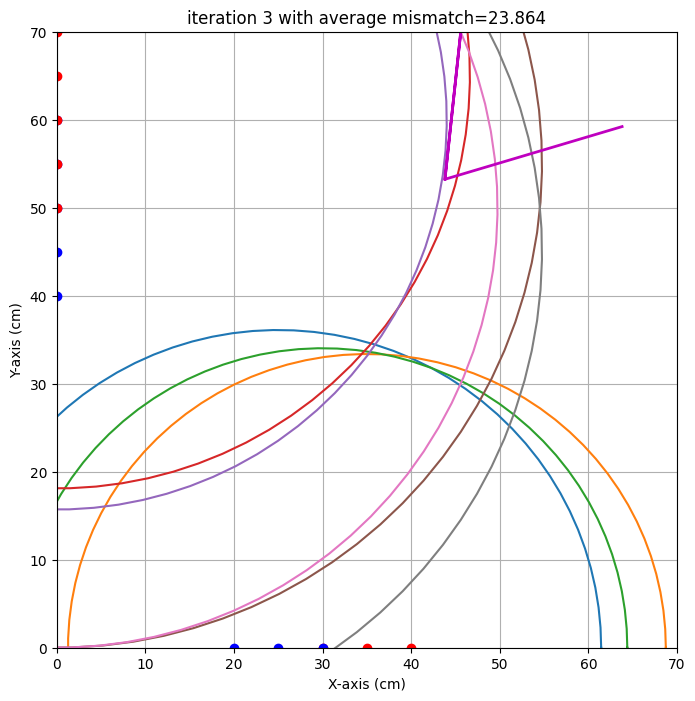

end iteration 3 with average mismatch=23.864
end iteration 4 with average mismatch=23.213
end iteration 5 with average mismatch=22.150
end iteration 6 with average mismatch=20.903


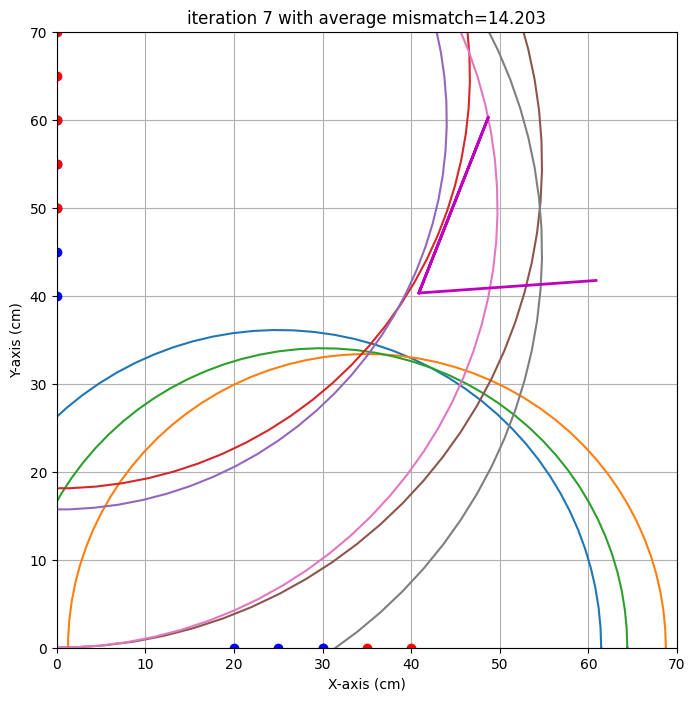

end iteration 7 with average mismatch=14.203


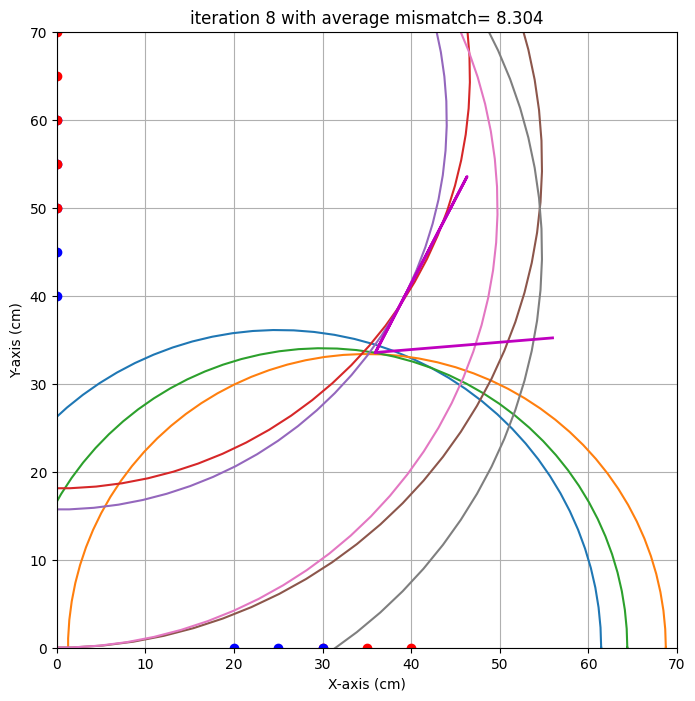

end iteration 8 with average mismatch= 8.304


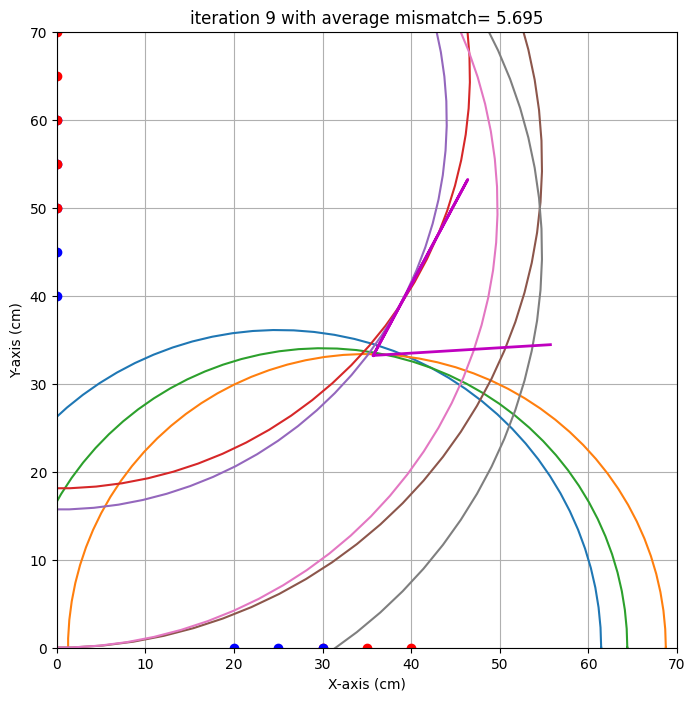

end iteration 9 with average mismatch= 5.695
end iteration 10 with average mismatch= 5.695
end iteration 11 with average mismatch= 5.695
end iteration 12 with average mismatch= 5.682
end iteration 13 with average mismatch= 5.218


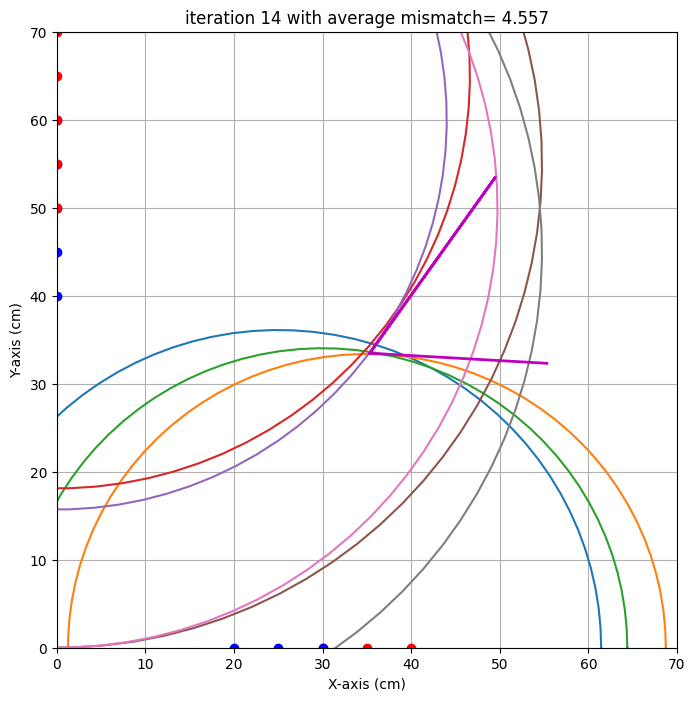

end iteration 14 with average mismatch= 4.557
end iteration 15 with average mismatch= 4.557
end iteration 16 with average mismatch= 4.557
end iteration 17 with average mismatch= 4.557
end iteration 18 with average mismatch= 4.557
end iteration 19 with average mismatch= 4.557
end iteration 20 with average mismatch= 4.557
end iteration 21 with average mismatch= 4.557
end iteration 22 with average mismatch= 4.557
end iteration 23 with average mismatch= 4.557
end iteration 24 with average mismatch= 4.557
end iteration 25 with average mismatch= 4.557
end iteration 26 with average mismatch= 4.557
end iteration 27 with average mismatch= 4.510
end iteration 28 with average mismatch= 4.510
end iteration 29 with average mismatch= 4.510
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 4.510
###############################################################################
end 

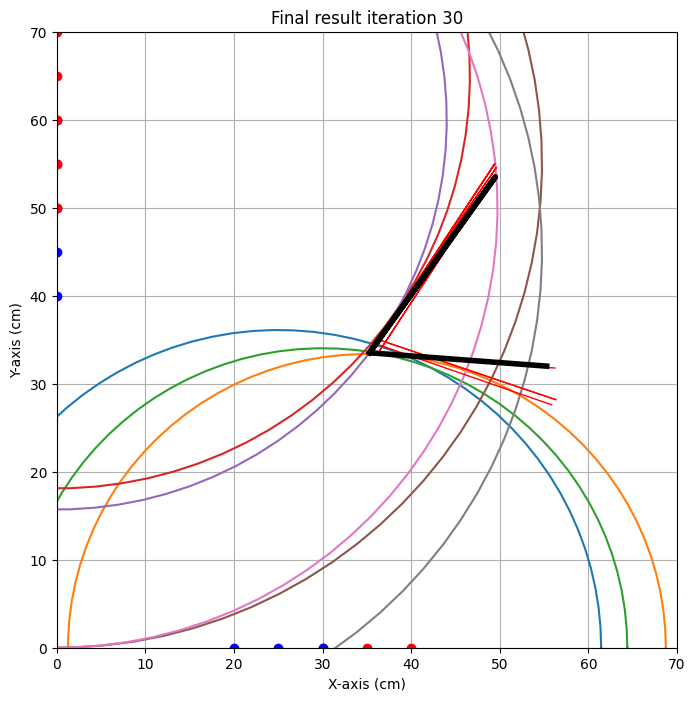

{'alpha': np.float64(-4.3486253108059), 'alpha_eps': np.float64(14.890755686649655), 'beta': np.float64(35.40661529010832), 'beta_eps': np.float64(2.3302481924674368), 'x0': np.float64(35.294421469696445), 'x0_eps': np.float64(1.0315970600794273), 'y0': np.float64(33.51874557275886), 'y0_eps': np.float64(1.4832541612723986)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  110.0
1   0  65   0  55  105.0
2   0  60   0  50  100.0
3   0  55   0  45  105.0
4   0  50   0  40  120.0
5  67   0  57   0  110.0
6  60   0  50   0  107.5
7  55   0  45   0  108.0


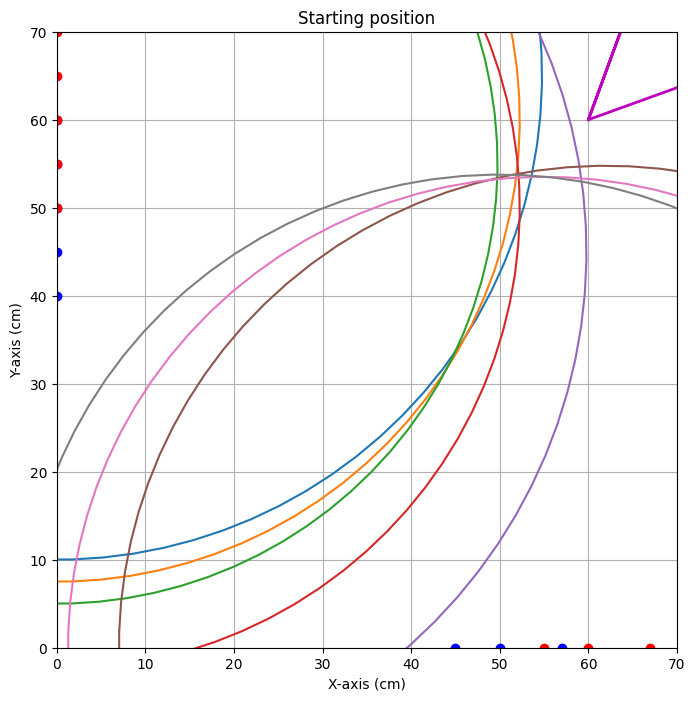


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...



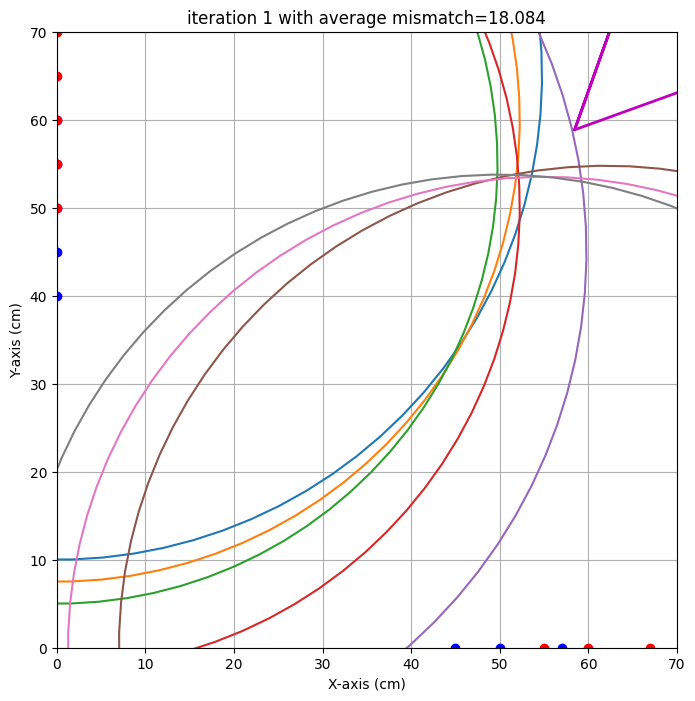

end iteration 1 with average mismatch=18.084


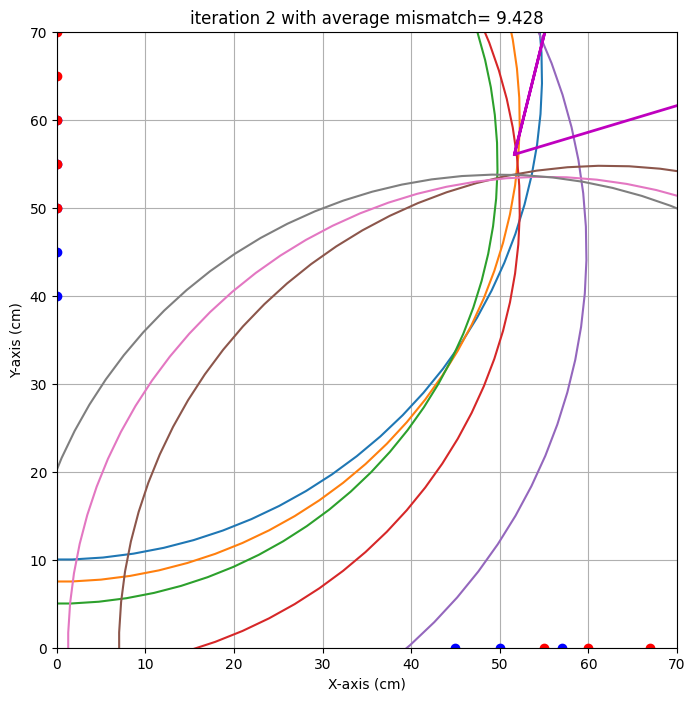

end iteration 2 with average mismatch= 9.428


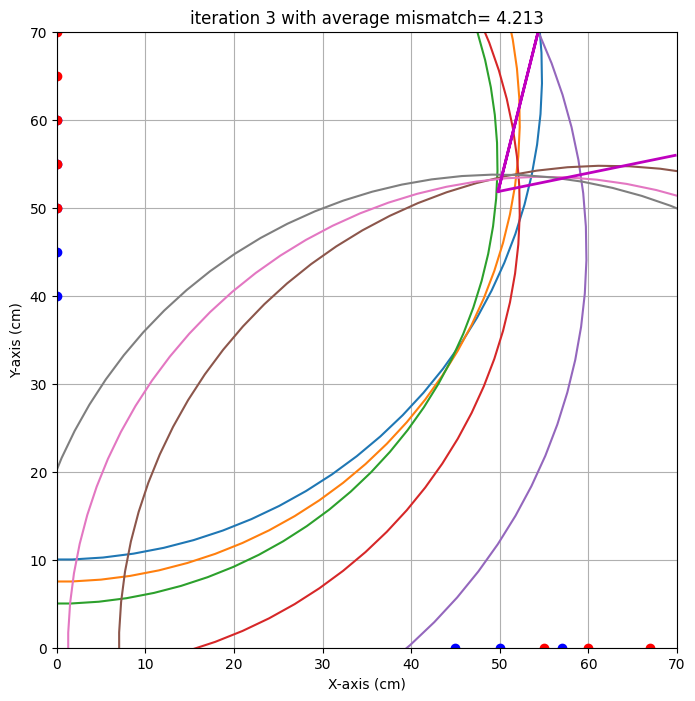

end iteration 3 with average mismatch= 4.213


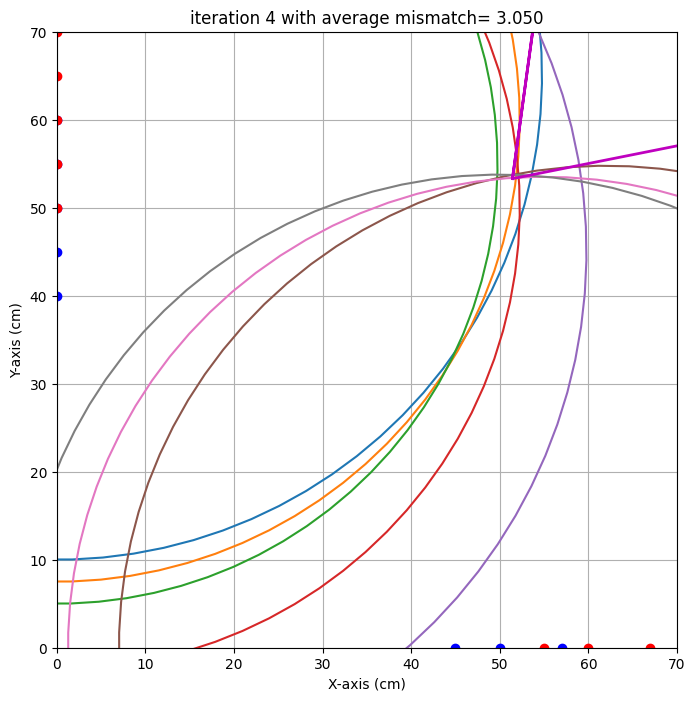

end iteration 4 with average mismatch= 3.050
end iteration 5 with average mismatch= 3.013
end iteration 6 with average mismatch= 3.011
end iteration 7 with average mismatch= 2.841
end iteration 8 with average mismatch= 2.816
end iteration 9 with average mismatch= 2.816
end iteration 10 with average mismatch= 2.816
end iteration 11 with average mismatch= 2.697
end iteration 12 with average mismatch= 2.689
end iteration 13 with average mismatch= 2.431
end iteration 14 with average mismatch= 2.431
end iteration 15 with average mismatch= 2.431
end iteration 16 with average mismatch= 2.431
end iteration 17 with average mismatch= 2.431
end iteration 18 with average mismatch= 2.431
end iteration 19 with average mismatch= 2.431
end iteration 20 with average mismatch= 2.413
end iteration 21 with average mismatch= 2.413
end iteration 22 with average mismatch= 2.413
end iteration 23 with average mismatch= 2.399
end iteration 24 with average mismatch= 2.399
end iteration 25 with average mismatch= 

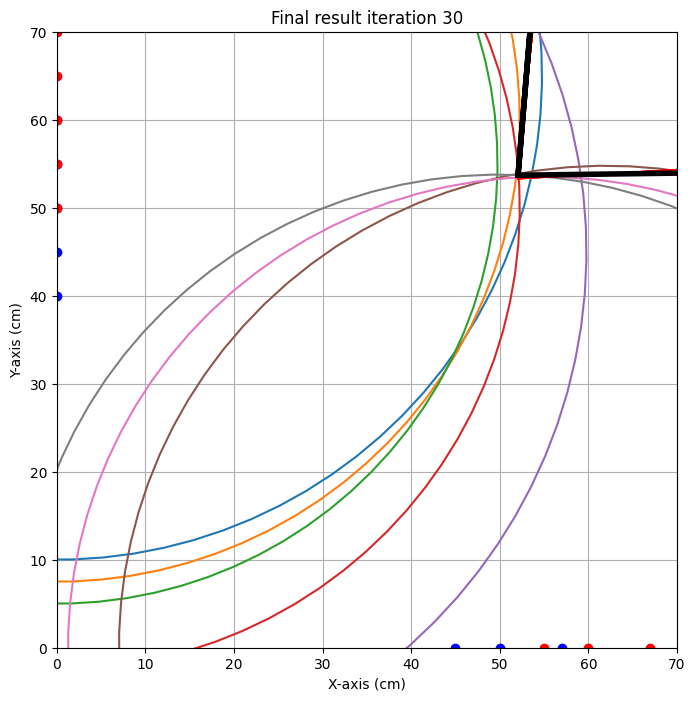

{'alpha': np.float64(0.7714450183530109), 'alpha_eps': np.float64(2.5666458342329688), 'beta': np.float64(4.727700429460177), 'beta_eps': np.float64(0.9305664452815732), 'x0': np.float64(52.064521144289266), 'x0_eps': np.float64(0.02105071393453528), 'y0': np.float64(53.69050163835839), 'y0_eps': np.float64(0.4018608108796897)}
locatie 1 
x0 target is : 35.4. Gevonden waarde: 35.3 cm met een standaardafwijking van 1.0 cm 
y0 target is : 34.3. Gevonden waarde: 33.5 cm met een standaardafwijking van 1.5 cm 
alpha target is : -9.0. Gevonden waarde: -4.3 graden met een standaardafwijking van 14.9 graad 
beta target is : 36.0. Gevonden waarde: 35.4 graden met een standaardafwijking van 2.3 graad 

locatie 2 
x0 target is : 45.4. Gevonden waarde: 52.1 cm met een standaardafwijking van 0.0 cm 
y0 target is : 52.4. Gevonden waarde: 53.7 cm met een standaardafwijking van 0.4 cm 
alpha target is : 11.0. Gevonden waarde: 0.8 graden met een standaardafwijking van 2.6 graad 
beta target is : 39.0. 

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 35.4, 
                    'y0': 34.3,
                    'alpha' : -9,
                    'beta' : 36},
            'locatie 2':{'x0': 45.4, 
                    'y0': 52.4,
                    'alpha' : 11,
                    'beta' : 39},
}

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[70,0,60,0,170] ongeldig
    [30,0,20,0,72.9],
    [40,0,30,0,67.5],
    [35,0,25,0,68.8],
    #[25,0,15,0,150] ongeldig
    # dus [20,0,10,0] ook ongeldig
    [0,70,0,60,93.8],
    [0,65,0,55,88.6],
    [0,60,0,50,110.0],
    [0,55,0,45,100],
    [0,50,0,40,110]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
        [0,70,0,60,110],
        [0,65,0,55,105],
        [0,60,0,50,100],
        [0,55,0,45,105],
        [0,50,0,40,120],
        [67,0,57,0,110],
        [60,0,50,0,107.5],
        [55,0,45,0,108]
        #[50,0,40,0,170] ongeldig
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  30   0  20  51.0
1   0  40   0  30  48.0
2  40   0  30   0  55.0
3  35   0  25   0  54.0


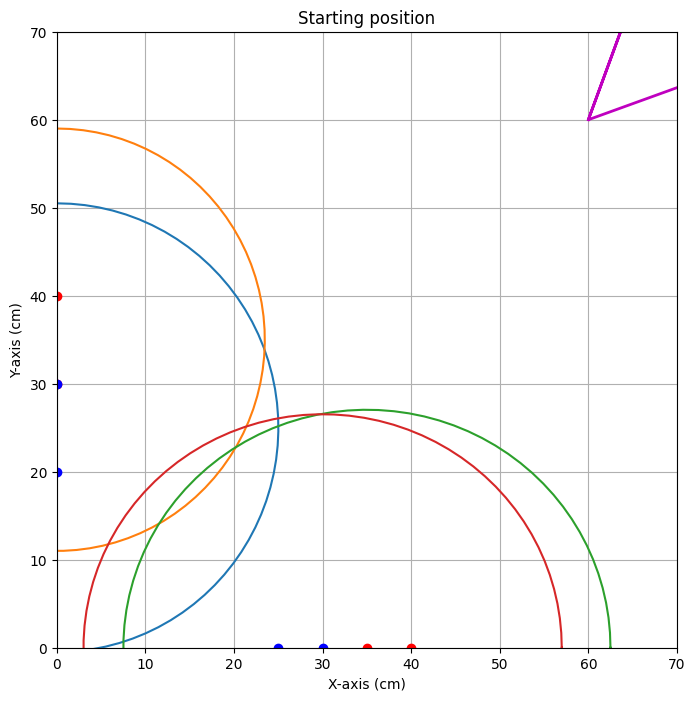


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=88.815


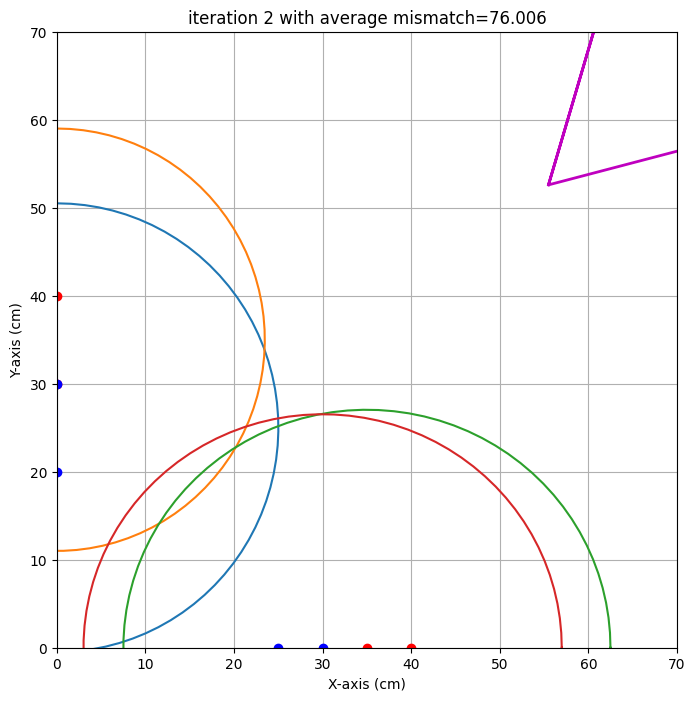

end iteration 2 with average mismatch=76.006


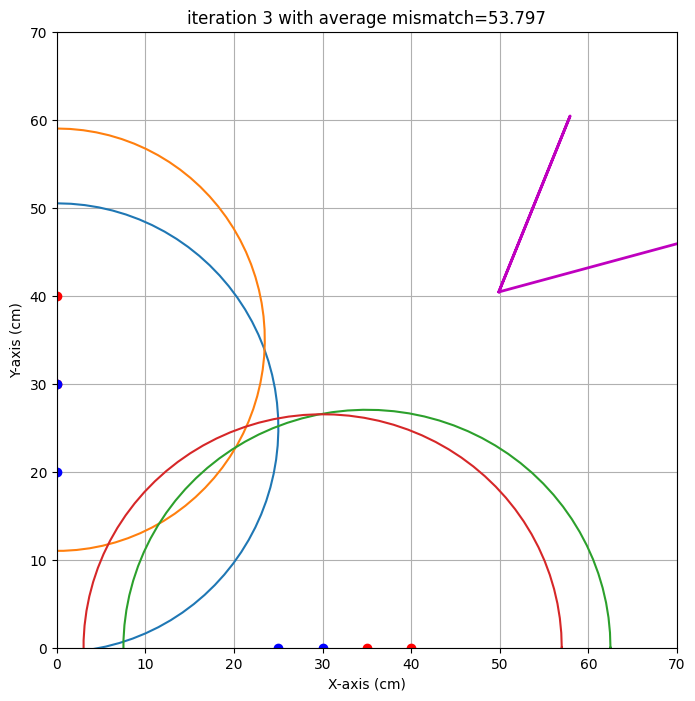

end iteration 3 with average mismatch=53.797


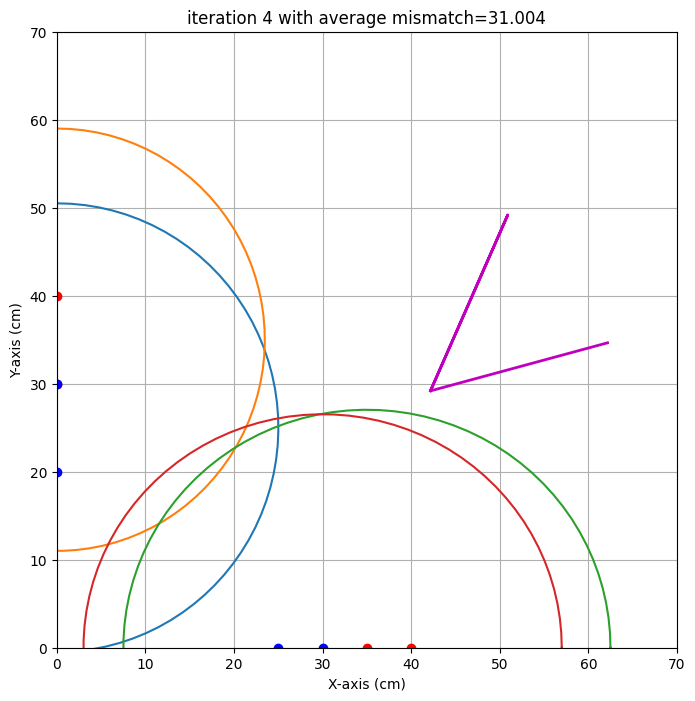

end iteration 4 with average mismatch=31.004


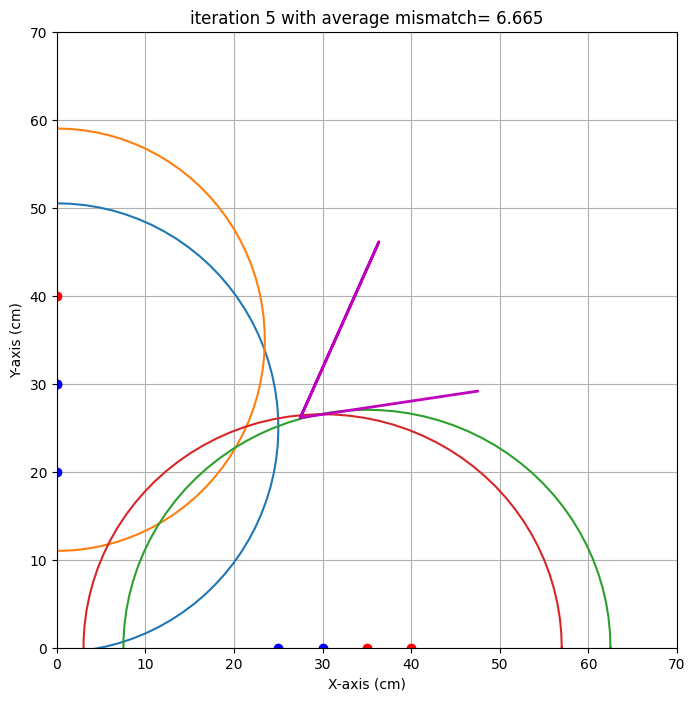

end iteration 5 with average mismatch= 6.665


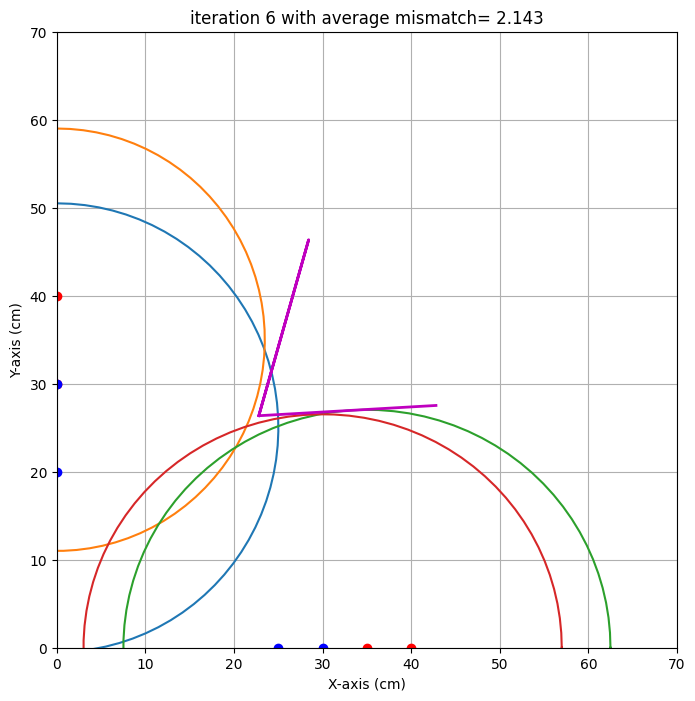

end iteration 6 with average mismatch= 2.143


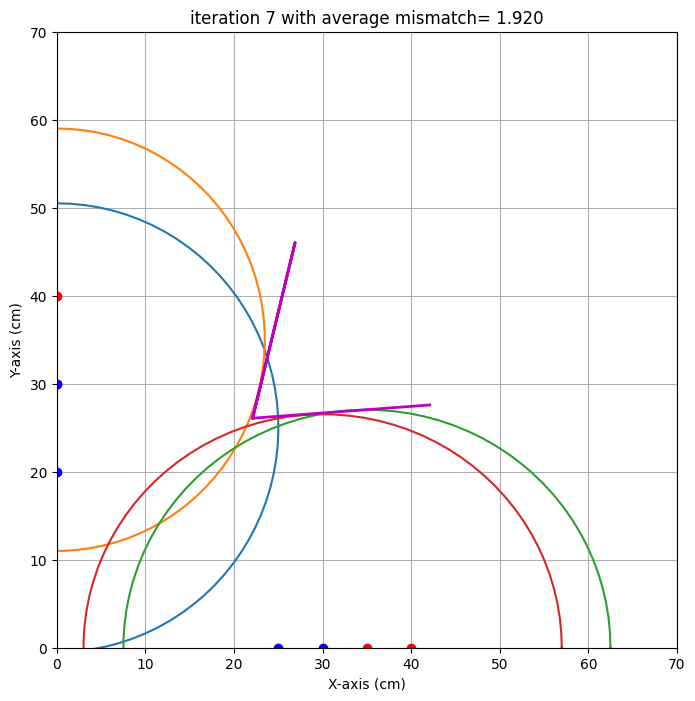

end iteration 7 with average mismatch= 1.920
end iteration 8 with average mismatch= 1.821
end iteration 9 with average mismatch= 1.807
end iteration 10 with average mismatch= 1.802


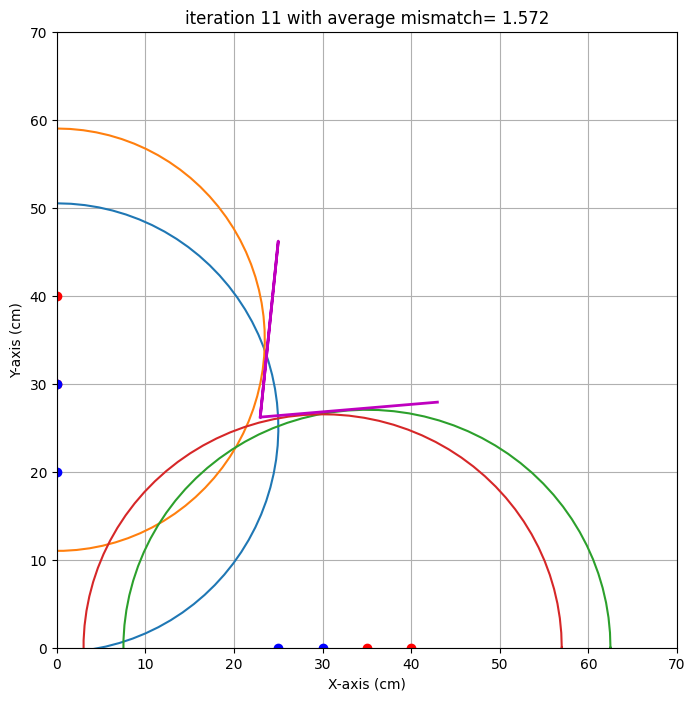

end iteration 11 with average mismatch= 1.572
end iteration 12 with average mismatch= 1.529
end iteration 13 with average mismatch= 1.433
end iteration 14 with average mismatch= 1.432


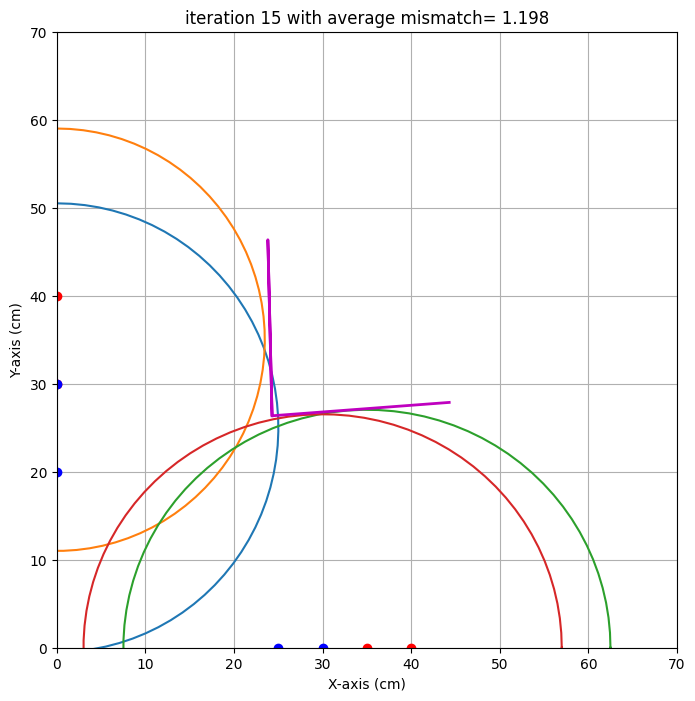

end iteration 15 with average mismatch= 1.198


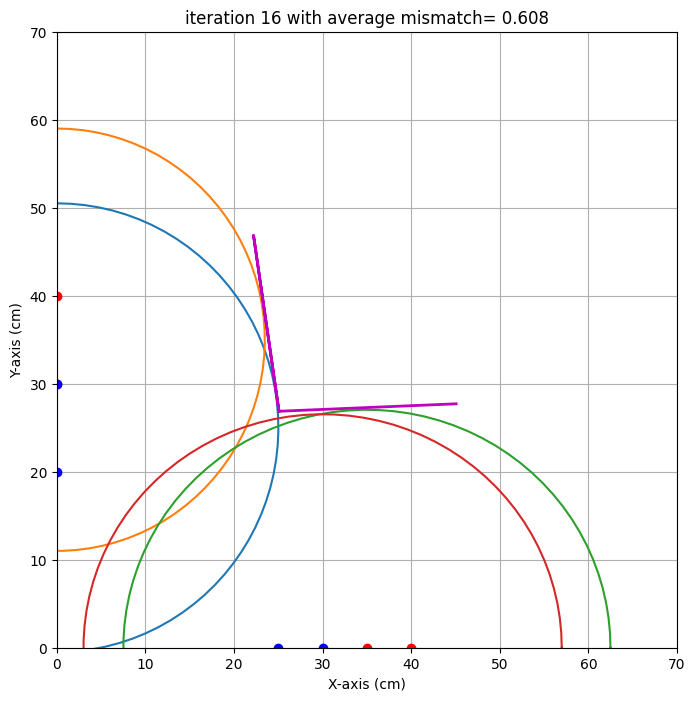

end iteration 16 with average mismatch= 0.608


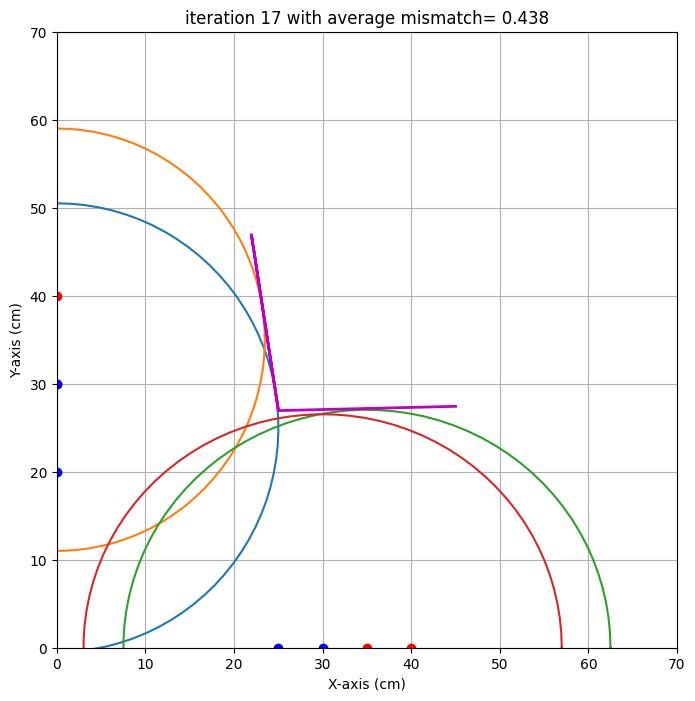

end iteration 17 with average mismatch= 0.438
end iteration 18 with average mismatch= 0.425


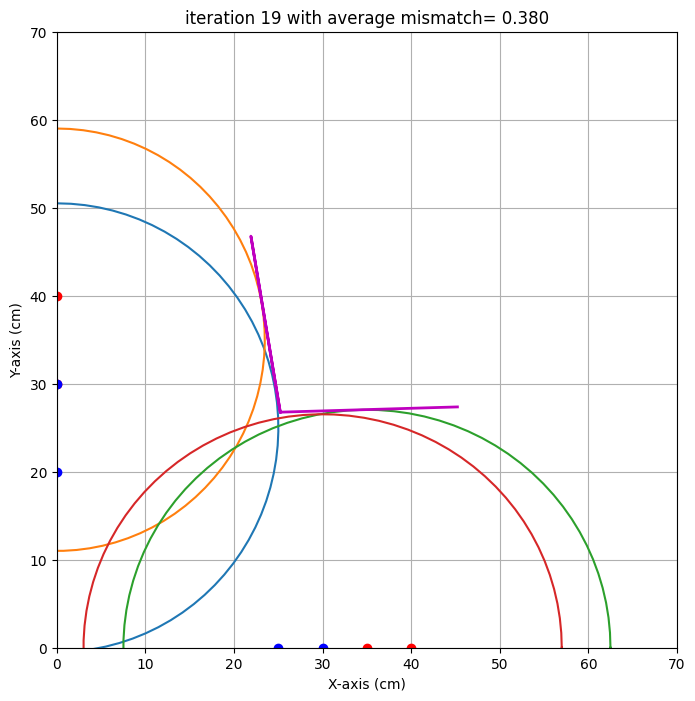

end iteration 19 with average mismatch= 0.380
end iteration 20 with average mismatch= 0.363
end iteration 21 with average mismatch= 0.357
end iteration 22 with average mismatch= 0.350


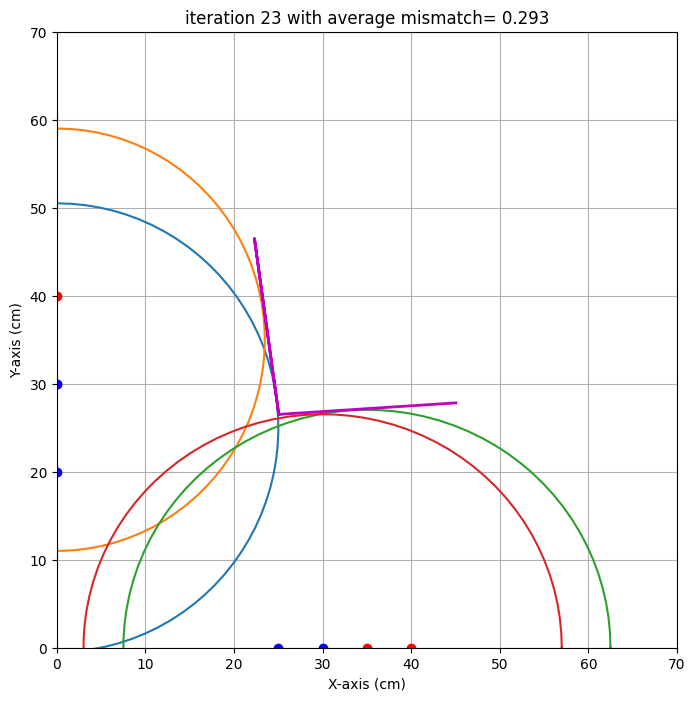

end iteration 23 with average mismatch= 0.293
end iteration 24 with average mismatch= 0.275
end iteration 25 with average mismatch= 0.272
end iteration 26 with average mismatch= 0.271
end iteration 27 with average mismatch= 0.271
end iteration 28 with average mismatch= 0.271
end iteration 29 with average mismatch= 0.253
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....


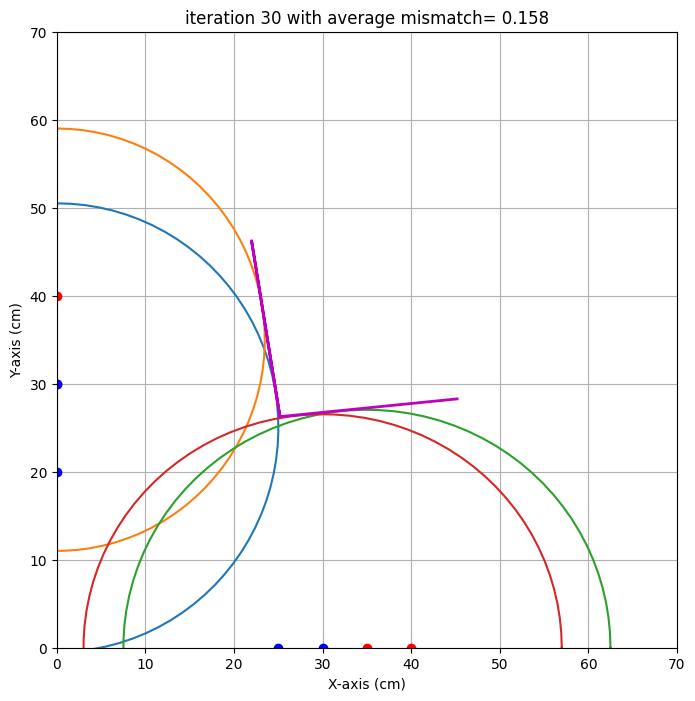

end iteration 30 with average mismatch= 0.158
###############################################################################
end of iteration  30
Best alpha=   5.76 with uncertainty=   1.33
Best beta =  -9.12 with uncertainty=   0.62
Best x0   =  25.19 with uncertainty=   0.06
Best y0   =  26.26 with uncertainty=   0.11
###############################################################################


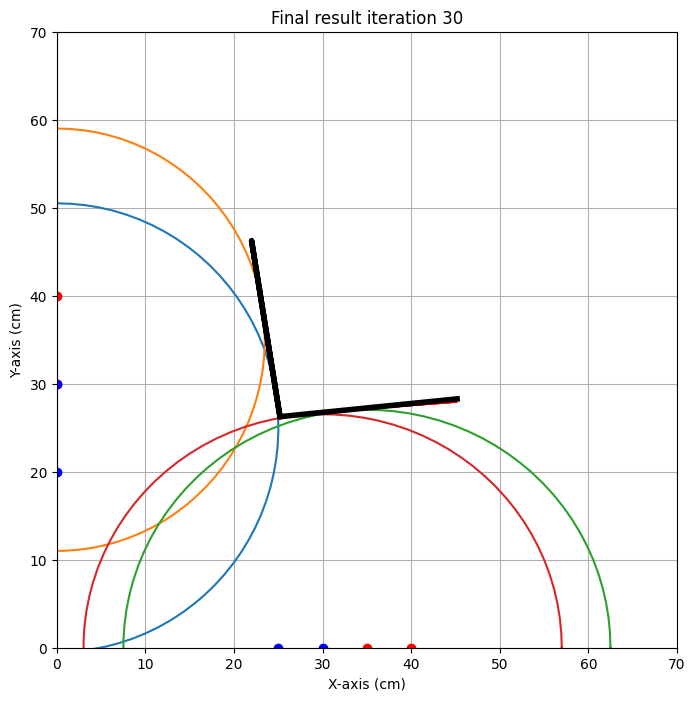

{'alpha': np.float64(5.764143701770746), 'alpha_eps': np.float64(1.3347452365822168), 'beta': np.float64(-9.116406558376456), 'beta_eps': np.float64(0.617884735037098), 'x0': np.float64(25.185269888169827), 'x0_eps': np.float64(0.06384107216703683), 'y0': np.float64(26.257552010605064), 'y0_eps': np.float64(0.11348821159874944)}
test locatie 
x0 target is : 26.4. Gevonden waarde: 25.2 cm met een standaardafwijking van 0.1 cm 
y0 target is : 25.2. Gevonden waarde: 26.3 cm met een standaardafwijking van 0.1 cm 
alpha target is : 10.0. Gevonden waarde: 5.8 graden met een standaardafwijking van 1.3 graad 
beta target is : -10.0. Gevonden waarde: -9.1 graden met een standaardafwijking van 0.6 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA

targets = {'test locatie':{
                    'x0': 26.4,
                    'y0': 25.2,
                    'alpha' : 10,
                    'beta' :  -10,
                          }
            }

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    #[0,70,0,60,170],
                    [0,30,0,20,51.0],
                    [0,40,0,30,48],
                    #[0,20,0,10,150] ongeldig
                    #[70,0,60,0,170] ongeldig
                    #[30,0,20,0,105],
                    [40,0,30,0,55],
                    [35,0,25,0,54],
                    #[30,0,20,0,105]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.

Leerdoel 1: inzien dat het maken van een algoritme een ontwerpcyclus is.
#### algoritme [Tim]
Voeg een foto in van het algoritme van het eerste groepslid
<img src="Tim.png" width="400">

#### algoritme [Marjoksi]
Voeg een foto in van het algoritme van het tweede groepslid
<img src="Marjoksi.png" width="400">

#### algoritme [Steven]
Voeg een foto in van het algoritme van het derde groepslid
<img src="Steven.png" width="400">

Nadat we inzagen dat we het verkeerd begrepen hadden, hebben we het meetalgoritme verbeterd tot onze uiteindelijke algoritme:
Figuur: ![Alt](Eindalgoritme.png)



Leerdoel 2: De ontwerpcyclus optimaal inrichten op de randvoorwaarden van de ontwerpopdracht:
Zie fotos